# Exploratory Data Analysis (EDA)
## DATA 407 Project: Estimating Airbnb Nightly Prices in Vancouver Using Sampling Methods
Taksh Girdhar - 27012699

### 1. Project Goal

The goal of this project is to estimate the mean nightly Airbnb price in Vancouver and examine how Airbnb prices vary across neighbourhoods. The analysis is based on the Inside Airbnb Vancouver listings dataset, which serves as the sampling frame for the study. 

This notebook focuses on exploratory data analysis (EDA) and data preparation for the later sampling components of the project. In particular, it is used to understand the structure of the dataset, assess missingness in key variables such as price, inspect the distribution of nightly prices, and evaluate whether neighbourhood is a strong candidate for stratification. 

The later stages of the project will apply simple random sampling (SRS), stratified random sampling by neighbourhood, and a separate ratio estimation analysis using number of reviews as an auxiliary variable. The EDA in this notebook is intended to support those later design and estimation choices.

### 2. Dataset Description

The dataset used in this project comes from the **Inside Airbnb Vancouver listings data**, which is used as the sampling frame for estimating Airbnb nightly prices in Vancouver. 


In the current working dataset, there are **4,705 listings** and **79 variables**, where each row represents a single Airbnb listing. The dataset contains a mix of listing-level information, host characteristics, location variables, room and property details, availability measures, and review-related variables as of 17th October 2025.

For this project, the most important variables are:

- **`price`**: nightly listed price of the Airbnb, which is the main outcome variable
- **`neighbourhood_cleansed`**: cleaned neighbourhood label, which will be used for stratified sampling
- **`room_type`**: type of listing (for example, entire home, private room), useful for descriptive analysis
- **`number_of_reviews`**: review count, which will later be used as the auxiliary variable in the ratio estimation analysis
- **`host_id`** and **`id`**: identifiers for hosts and listings, useful for checking duplicates or repeated host activity

The dataset also includes other potentially useful descriptive variables such as `property_type`, `accommodates`, `bedrooms`, `bathrooms`, review score variables, and estimated revenue measures. However, the main focus of this notebook is on understanding the structure and quality of the data needed for the sampling analysis.


### 3. Imports and Setup

This section imports the libraries used for data cleaning, exploration, and visualization. It also sets display and plotting options to make the notebook easier to read, and fixes a random seed for reproducibility in later sampling steps.

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional utilities
import warnings
from pathlib import Path


# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 8)

# Reproducibility
RANDOM_SEED = 88
np.random.seed(RANDOM_SEED)


### 4. Load the Data

In this section, the Airbnb listings dataset is loaded into Python and its overall structure is inspected. The goal is to confirm that the data has been read correctly, identify the number of observations and variables, and verify that the key columns needed for the project are present.

In [4]:
df = pd.read_csv('data/listings.csv')
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (4705, 79)
Number of rows: 4705
Number of columns: 79


In [5]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13188,https://www.airbnb.com/rooms/13188,20251017043359,2025-10-17,city scrape,Garden level studio in ideal loc.,Garden level studio suite with garden patio - in a trendy and very central area of Vancouver. Lo...,The uber hip Main street area is a short walk of 6 minutes to the east. Dozens of dining option...,https://a0.muscache.com/pictures/8408188/e1af63e4_original.jpg,51466,https://www.airbnb.com/users/show/51466,Emma,2009-11-04,"Vancouver, Canada",I love to travel with my family in comfort and enjoy the ethos and community spirit of AirBNB. I...,within a few hours,100%,100%,t,https://a0.muscache.com/im/pictures/user/User/original/484b2335-be00-413e-bab2-f82fe48361c0.jpeg...,https://a0.muscache.com/im/pictures/user/User/original/484b2335-be00-413e-bab2-f82fe48361c0.jpeg...,Riley Park,1,3,"['email', 'phone']",t,t,Neighborhood highlights,Riley Park,NaN,49.25,-123.11,Entire guest suite,Entire home/apt,4,1.00,1 bath,0.00,2.00,"[""Bathtub"", ""Dishes and silverware"", ""Shampoo"", ""Refrigerator"", ""Toaster"", ""Luggage dropoff allo...",$138.00,2,180,2.00,2.00,180.00,180.00,2.00,180.00,NaN,t,0,0,17,164,2025-10-17,381,44,0,3,60,255,"35,190.00",2010-02-21,2025-09-16,4.85,4.89,4.86,4.87,4.93,4.91,4.81,Municipal registration number: 25-156058<br />Provincial registration number: H403372913,f,1,1,0,0,2.00
1,18270,https://www.airbnb.com/rooms/18270,20251017043359,2025-10-17,city scrape,private rm in clean central 2BR apt,I have a bright furnished 2 bedroom suite on a quiet street in central vibrant part of Vancouver...,"Lots of restaurants, coffee shops.<br />Easy access to public transport in multiple directions.<...",https://a0.muscache.com/pictures/108520241/aeca9591_original.jpg,70437,https://www.airbnb.com/users/show/70437,Ran,2010-01-14,"Vancouver, Canada","In my spare time I am pretty active - currently with beach volleyball, hiking, orienteering, swi...",NaN,NaN,NaN,f,https://a0.muscache.com/im/pictures/user/User-70437/original/7d40c816-a999-4c47-a5af-7018b87edd9...,https://a0.muscache.com/im/pictures/user/User-70437/original/7d40c816-a999-4c47-a5af-7018b87edd9...,Mount Pleasant,1,4,"['email', 'phone']",t,t,Neighborhood highlights,Mount Pleasant,NaN,49.27,-123.10,Private room in condo,Private room,2,1.00,1 shared bath,1.00,1.00,"[""Dishes and silverware"", ""Shampoo"", ""Refrigerator"", ""Free parking on premises"", ""Park view"", ""E...",$47.00,90,1125,90.00,90.00,"1,125.00","1,125.00",90.00,"1,125.00",NaN,t,22,43,65,261,2025-10-17,118,0,0,55,0,0,0.00,2011-03-17,2019-12-31,4.54,4.50,3.98,4.75,4.73,4.69,4.49,NaN,f,1,0,1,0,0.66
2,18589,ht

In [6]:
df.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4705 entries, 0 to 4704
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4705 non-null   int64  
 1   listing_url                                   4705 non-null   object 
 2   scrape_id                                     4705 non-null   int64  
 3   last_scraped                                  4705 non-null   object 
 4   source                                        4705 non-null   object 
 5   name                                          4705 non-null   object 
 6   description                                   4670 non-null   object 
 7   neighborhood_overview                         2275 non-null   object 
 8   picture_url                                   4705 non-null   object 
 9   host_id                                       4705 non-null   i

### 5. Data Quality Overview

Before cleaning the main analysis variables, it is important to assess the overall quality of the raw dataset. This includes checking for missing values, duplicate observations, identifier uniqueness, and the completeness of the key variables needed for the sampling analysis.

This step is especially important because the project proposal identifies missing price values as a potential source of non-response bias. The purpose of this section is not to clean the data yet, but to identify issues that will need to be addressed in later steps. 

In [8]:
# Missing values summary
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_pct
}).sort_values("missing_count", ascending=False)

missing_summary.head(20)

,missing_count,missing_percent
calendar_updated,4705,100.00
neighbourhood_group_cleansed,4705,100.00
neighbourhood,2430,51.65
neighborhood_overview,2430,51.65
host_about,2355,50.05
host_location,1095,23.27
license,1061,22.55
last_review,641,13.62
review_scores_rating,641,13.62
review_scores_accuracy,641,13.62


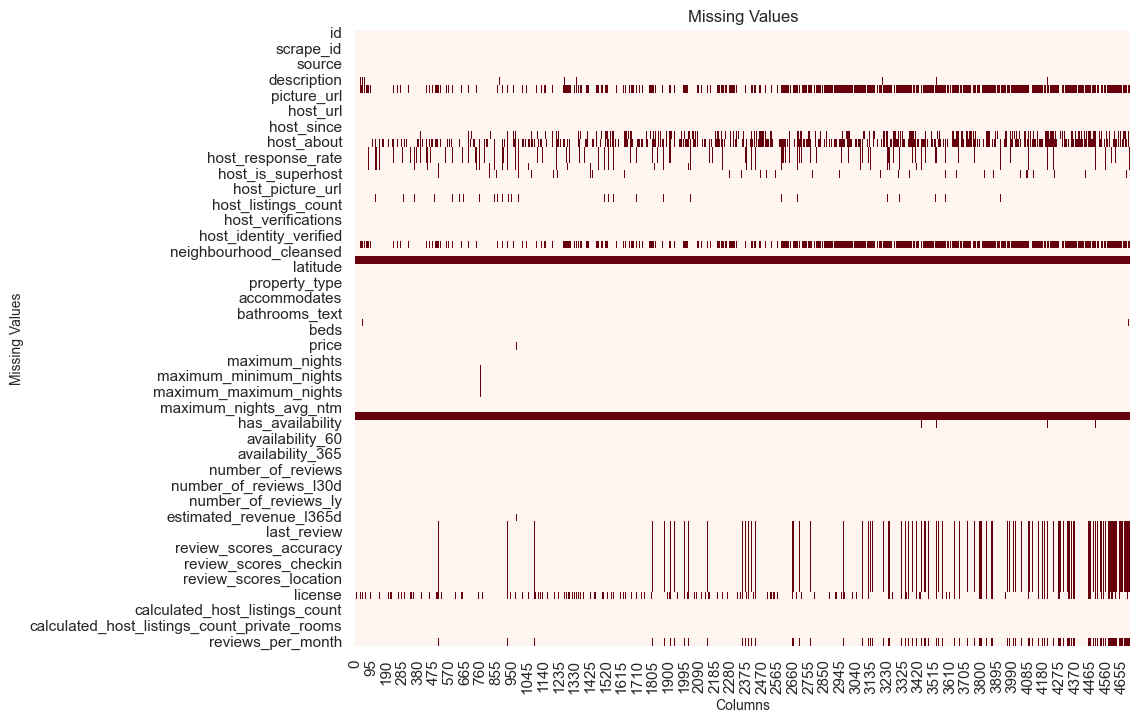

In [9]:
ax = plt.axes()
sns.heatmap(df.isna().transpose(), cmap="Reds", cbar=False, ax=ax)
plt.title("Missing Values", fontsize=12)
plt.xlabel("Columns", fontsize = 10) 
plt.ylabel("Missing Values", fontsize = 10)
plt.show()

In [10]:
key_vars = ["id", "price", "neighbourhood_cleansed", "room_type", "number_of_reviews", "host_id"]

key_missing_summary = pd.DataFrame({
    "missing_count": df[key_vars].isnull().sum(),
    "missing_percent": (df[key_vars].isnull().mean() * 100).round(2),
    "dtype": df[key_vars].dtypes.astype(str)
})

key_missing_summary

,missing_count,missing_percent,dtype
id,0,0.00,int64
price,3,0.06,object
neighbourhood_cleansed,0,0.00,object
room_type,0,0.00,object
number_of_reviews,0,0.00,int64
host_id,0,0.00,int64


In [11]:
# Check for fully duplicated rows
duplicate_rows = df.duplicated().sum()
print("Number of fully duplicated rows:", duplicate_rows)

Number of fully duplicated rows: 0


In [12]:
# Check uniqueness of listing ID
n_rows = len(df)
n_unique_ids = df["id"].nunique()

print("Total rows:", n_rows)
print("Unique listing IDs:", n_unique_ids)
print("Are listing IDs unique?", n_rows == n_unique_ids)

Total rows: 4705
Unique listing IDs: 4705
Are listing IDs unique? True


In [13]:
# Preview key variables
df[["id", "price", "neighbourhood_cleansed", "room_type", "number_of_reviews", "host_id"]].head(10)

,id,price,neighbourhood_cleansed,room_type,number_of_reviews,host_id
0,13188,$138.00,Riley Park,Entire home/apt,381,51466
1,18270,$47.00,Mount Pleasant,Private room,118,70437
2,18589,$140.00,Grandview-Woodland,Private room,632,71508
3,18795,$75.00,West End,Private room,131,70137
4,20085,$136.00,Kensington-Cedar Cottage,Entire home/apt,80,75986
5,24273,$171.00,Kitsilano,Entire home/apt,17,1267409
6,26047,$234.00,Downtown,Entire home/apt,49,109845
7,33150,$155.00,Riley Park,Entire home/apt,176,143724
8,35102,$110.00,Downtown,Entire home/apt,78,2283739
9,35304,$137.00,Grandview-Woodland,Entire home/apt,656,151996


In [14]:
# Columns with more than 50% missing values
high_missing = missing_summary[missing_summary["missing_percent"] > 50]
high_missing

,missing_count,missing_percent
calendar_updated,4705,100.00
neighbourhood_group_cleansed,4705,100.00
neighbourhood,2430,51.65
neighborhood_overview,2430,51.65
host_about,2355,50.05


The data quality checks suggest that the dataset is generally strong for the main analysis variables. The key project fields are almost fully complete: `id`, `host_id`, `room_type`, `number_of_reviews`, and `neighbourhood_cleansed` have no missing values, while `price` has only 3 missing observations out of 4,705. There are also no fully duplicated rows, and the listing identifier `id` is unique for every observation, which supports treating each row as a distinct Airbnb listing.

At the same time, several variables have substantial missingness. In particular, `calendar_updated` and `neighbourhood_group_cleansed` are completely empty and are not useful for this project. The raw `neighbourhood` field also has high missingness (51.65%), which should be acknowledged because neighbourhood is central to the proposed stratified sampling design. However, this issue is less concerning here because the cleaned neighbourhood variable, `neighbourhood_cleansed`, is fully complete and is the better choice for analysis and stratification. Overall, the results suggest that the dataset is suitable for the project, but the analysis should rely on the cleaned neighbourhood field rather than the raw `neighbourhood` column.

### 6. Cleaning Key Variables

This section prepares the main variables used in the project for analysis. The goal is to convert important fields into usable formats while preserving the full dataset for now. In particular, the nightly price variable must be cleaned from a character format into a numeric variable, and the cleaned neighbourhood field will be used in place of the raw neighbourhood field because it is complete and more appropriate for analysis.

At this stage, missing values are retained so they can be examined explicitly in the next section before defining the final analysis dataset. This keeps the cleaning process transparent and separates data preparation from later decisions about exclusion or estimation.

In [15]:
df_clean = df[[
    "id",
    "host_id",
    "price",
    "neighbourhood_cleansed",
    "room_type",
    "number_of_reviews",
    "property_type",
    "accommodates",
    "bedrooms",
    "bathrooms"
]].copy()

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13188,https://www.airbnb.com/rooms/13188,20251017043359,2025-10-17,city scrape,Garden level studio in ideal loc.,Garden level studio suite with garden patio - in a trendy and very central area of Vancouver. Lo...,The uber hip Main street area is a short walk of 6 minutes to the east. Dozens of dining option...,https://a0.muscache.com/pictures/8408188/e1af63e4_original.jpg,51466,https://www.airbnb.com/users/show/51466,Emma,2009-11-04,"Vancouver, Canada",I love to travel with my family in comfort and enjoy the ethos and community spirit of AirBNB. I...,within a few hours,100%,100%,t,https://a0.muscache.com/im/pictures/user/User/original/484b2335-be00-413e-bab2-f82fe48361c0.jpeg...,https://a0.muscache.com/im/pictures/user/User/original/484b2335-be00-413e-bab2-f82fe48361c0.jpeg...,Riley Park,1,3,"['email', 'phone']",t,t,Neighborhood highlights,Riley Park,NaN,49.25,-123.11,Entire guest suite,Entire home/apt,4,1.00,1 bath,0.00,2.00,"[""Bathtub"", ""Dishes and silverware"", ""Shampoo"", ""Refrigerator"", ""Toaster"", ""Luggage dropoff allo...",$138.00,2,180,2.00,2.00,180.00,180.00,2.00,180.00,NaN,t,0,0,17,164,2025-10-17,381,44,0,3,60,255,"35,190.00",2010-02-21,2025-09-16,4.85,4.89,4.86,4.87,4.93,4.91,4.81,Municipal registration number: 25-156058<br />Provincial registration number: H403372913,f,1,1,0,0,2.00
1,18270,https://www.airbnb.com/rooms/18270,20251017043359,2025-10-17,city scrape,private rm in clean central 2BR apt,I have a bright furnished 2 bedroom suite on a quiet street in central vibrant part of Vancouver...,"Lots of restaurants, coffee shops.<br />Easy access to public transport in multiple directions.<...",https://a0.muscache.com/pictures/108520241/aeca9591_original.jpg,70437,https://www.airbnb.com/users/show/70437,Ran,2010-01-14,"Vancouver, Canada","In my spare time I am pretty active - currently with beach volleyball, hiking, orienteering, swi...",NaN,NaN,NaN,f,https://a0.muscache.com/im/pictures/user/User-70437/original/7d40c816-a999-4c47-a5af-7018b87edd9...,https://a0.muscache.com/im/pictures/user/User-70437/original/7d40c816-a999-4c47-a5af-7018b87edd9...,Mount Pleasant,1,4,"['email', 'phone']",t,t,Neighborhood highlights,Mount Pleasant,NaN,49.27,-123.10,Private room in condo,Private room,2,1.00,1 shared bath,1.00,1.00,"[""Dishes and silverware"", ""Shampoo"", ""Refrigerator"", ""Free parking on premises"", ""Park view"", ""E...",$47.00,90,1125,90.00,90.00,"1,125.00","1,125.00",90.00,"1,125.00",NaN,t,22,43,65,261,2025-10-17,118,0,0,55,0,0,0.00,2011-03-17,2019-12-31,4.54,4.50,3.98,4.75,4.73,4.69,4.49,NaN,f,1,0,1,0,0.66
2,18589,ht

In [16]:
df_clean["price"].head(10)

0    $138.00
1     $47.00
2    $140.00
3     $75.00
4    $136.00
5    $171.00
6    $234.00
7    $155.00
8    $110.00
9    $137.00
Name: price, dtype: object

In [17]:
df_clean["price_raw"] = df_clean["price"]

df_clean["price"] = (
    df_clean["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .replace("nan", np.nan)
    .astype(float)
)

In [18]:
df_clean = df_clean.rename(columns={"neighbourhood_cleansed": "neighbourhood"})
df_clean[["id", "price_raw", "price", "neighbourhood", "room_type", "number_of_reviews"]].head(10)

,id,price_raw,price,neighbourhood,room_type,number_of_reviews
0,13188,$138.00,138.00,Riley Park,Entire home/apt,381
1,18270,$47.00,47.00,Mount Pleasant,Private room,118
2,18589,$140.00,140.00,Grandview-Woodland,Private room,632
3,18795,$75.00,75.00,West End,Private room,131
4,20085,$136.00,136.00,Kensington-Cedar Cottage,Entire home/apt,80
5,24273,$171.00,171.00,Kitsilano,Entire home/apt,17
6,26047,$234.00,234.00,Downtown,Entire home/apt,49
7,33150,$155.00,155.00,Riley Park,Entire home/apt,176
8,35102,$110.00,110.00,Downtown,Entire home/apt,78
9,35304,$137.00,137.00,Grandview-Woodland,Entire home/apt,656


In [19]:
df_clean[["price", "neighbourhood", "room_type", "number_of_reviews"]].isnull().sum()

price                3
neighbourhood        0
room_type            0
number_of_reviews    0
dtype: int64

In [20]:
df_clean["price"].describe()

count    4,702.00
mean       219.76
std        650.23
min         14.00
25%        108.00
50%        158.00
75%        239.00
max     40,896.00
Name: price, dtype: float64

### 7. Missing Price Analysis

Because price is the main outcome variable in this project, it is important to examine the extent and pattern of missingness before moving on to estimation. Since missing prices could be a possible source of non-response bias, so this section assesses whether missing price values are substantial in the current working dataset and whether they are concentrated in particular neighbourhoods or room types. 

The goal here is to determine whether missing price observations are likely to materially affect the later sampling analysis, and to document any exclusions that may be needed when constructing the final analysis dataset.

In [21]:
missing_price_count = df_clean["price"].isnull().sum()
missing_price_pct = df_clean["price"].isnull().mean() * 100

print("Missing price count:", missing_price_count)
print(f"Missing price percent: {missing_price_pct:.2f}%")

price_missing_table = df_clean["price"].isnull().value_counts().rename(index={False: "Observed", True: "Missing"})
price_missing_table

Missing price count: 3
Missing price percent: 0.06%


price
Observed    4702
Missing        3
Name: count, dtype: int64

In [22]:
missing_by_neighbourhood = (
    df_clean.assign(price_missing=df_clean["price"].isnull())
    .groupby("neighbourhood")
    .agg(
        total_listings=("price", "size"),
        missing_price_count=("price_missing", "sum"),
        missing_price_percent=("price_missing", lambda x: x.mean() * 100)
    )
    .sort_values("missing_price_count", ascending=False)
)

missing_by_neighbourhood.head(15)

,total_listings,missing_price_count,missing_price_percent
neighbourhood,,,
Downtown,1183,3,0.25
Arbutus Ridge,108,0,0.00
Mount Pleasant,306,0,0.00
West End,265,0,0.00
Victoria-Fraserview,147,0,0.00
Sunset,125,0,0.00
Strathcona,19,0,0.00
South Cambie,38,0,0.00
Shaughnessy,69,0,0.00


In [23]:
missing_by_room_type = (
    df_clean.assign(price_missing=df_clean["price"].isnull())
    .groupby("room_type")
    .agg(
        total_listings=("price", "size"),
        missing_price_count=("price_missing", "sum"),
        missing_price_percent=("price_missing", lambda x: x.mean() * 100)
    )
    .sort_values("missing_price_count", ascending=False)
)

missing_by_room_type

,total_listings,missing_price_count,missing_price_percent
room_type,,,
Entire home/apt,3749,3,0.08
Private room,942,0,0.00
Shared room,14,0,0.00


In [24]:
df_clean[df_clean["price"].isnull()][["id", "neighbourhood", "room_type", "property_type", "accommodates", "bedrooms", "bathrooms", "number_of_reviews"]]

,id,neighbourhood,room_type,property_type,accommodates,bedrooms,bathrooms,number_of_reviews
707,31444945,Downtown,Entire home/apt,Entire serviced apartment,2,0.00,1.00,426
709,31445122,Downtown,Entire home/apt,Entire serviced apartment,4,1.00,1.00,183
978,42813067,Downtown,Entire home/apt,Entire serviced apartment,6,2.00,2.00,32


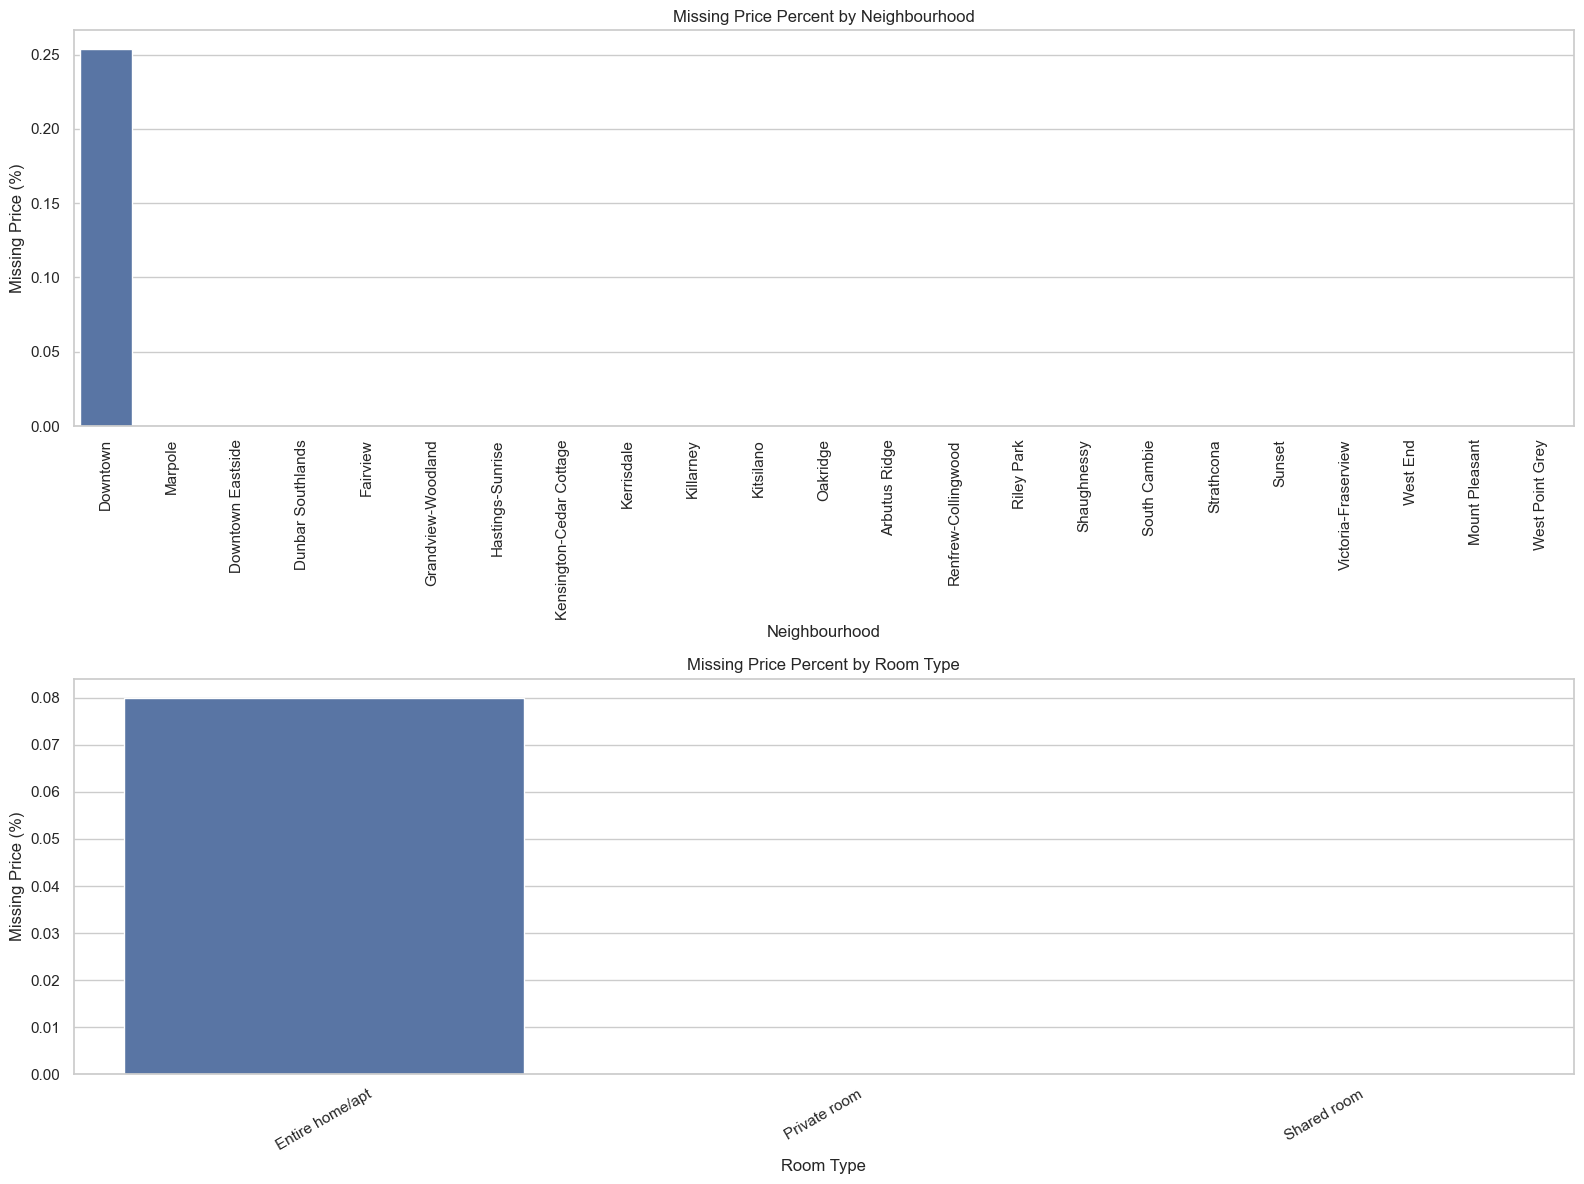

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Missing price percent by neighbourhood
missing_neigh_plot = missing_by_neighbourhood.reset_index().sort_values(
    "missing_price_percent", ascending=False
)

sns.barplot(
    data=missing_neigh_plot,
    x="neighbourhood",
    y="missing_price_percent",
    ax=axes[0]
)
axes[0].set_title("Missing Price Percent by Neighbourhood")
axes[0].set_xlabel("Neighbourhood")
axes[0].set_ylabel("Missing Price (%)")
axes[0].tick_params(axis="x", rotation=90)

# Plot 2: Missing price percent by room type
missing_room_plot = missing_by_room_type.reset_index().sort_values(
    "missing_price_percent", ascending=False
)

sns.barplot(
    data=missing_room_plot,
    x="room_type",
    y="missing_price_percent",
    ax=axes[1]
)
axes[1].set_title("Missing Price Percent by Room Type")
axes[1].set_xlabel("Room Type")
axes[1].set_ylabel("Missing Price (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

The missing price analysis shows that missingness in the main outcome variable is extremely limited in the current working dataset. Only **3 out of 4,705 listings** have a missing nightly price, which corresponds to just **0.06%** of all observations. This suggests that missing price data is not a major concern for the current analysis and is unlikely to materially affect the estimation of the population mean.

Looking across groups, all three missing price observations occur in the **Downtown** neighbourhood, where the missing price rate is still only **0.25%**. By room type, the missing values appear only among **Entire home/apt** listings, with a missingness rate of **0.08%**. Since the number of missing cases is so small and the percentages remain very low within each group, there is little evidence that price missingness is widespread or severe enough to distort the later sampling analysis.

Overall, these results suggest that the missing price issue is minor in this version of the dataset. For the main estimation and simulation stages, the three listings with missing prices can reasonably be excluded when defining the final analysis dataset, with only a brief note that missing-price bias appears negligible here.

### 8. Price Distribution Overview

Since price is the main outcome variable in this project, it is important to first understand its overall distribution before moving on to estimation and group comparisons. This section summarizes the distribution of nightly Airbnb prices across all listings with observed prices.

The purpose of this section is to examine the centre, spread, and shape of the price variable, and to identify whether extreme values may influence the mean. This is especially relevant because the project focuses on estimating the mean nightly price.

In [26]:
price_stats = pd.Series({
    "count": df_clean["price"].count(),
    "mean": df_clean["price"].mean(),
    "median": df_clean["price"].median(),
    "std": df_clean["price"].std(),
    "min": df_clean["price"].min(),
    "q1": df_clean["price"].quantile(0.25),
    "q3": df_clean["price"].quantile(0.75),
    "max": df_clean["price"].max(),
    "iqr": df_clean["price"].quantile(0.75) - df_clean["price"].quantile(0.25)
})

price_stats

count     4,702.00
mean        219.76
median      158.00
std         650.23
min          14.00
q1          108.00
q3          239.00
max      40,896.00
iqr         131.00
dtype: float64

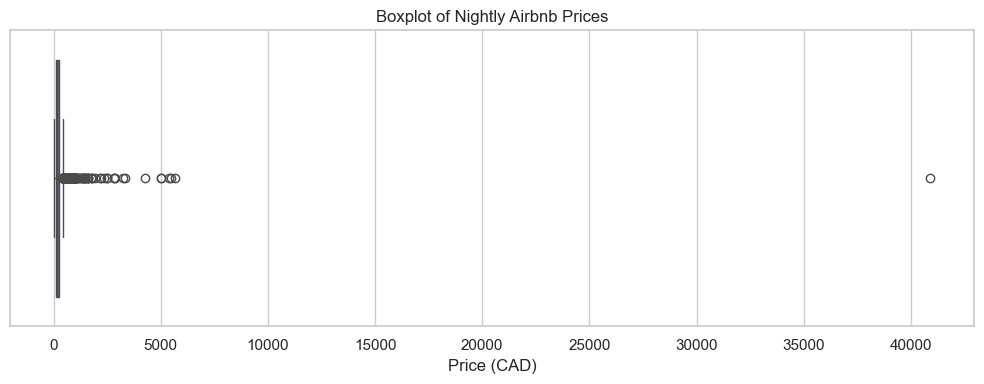

In [27]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_clean, x="price")
plt.title("Boxplot of Nightly Airbnb Prices")
plt.xlabel("Price (CAD)")
plt.tight_layout()
plt.show()

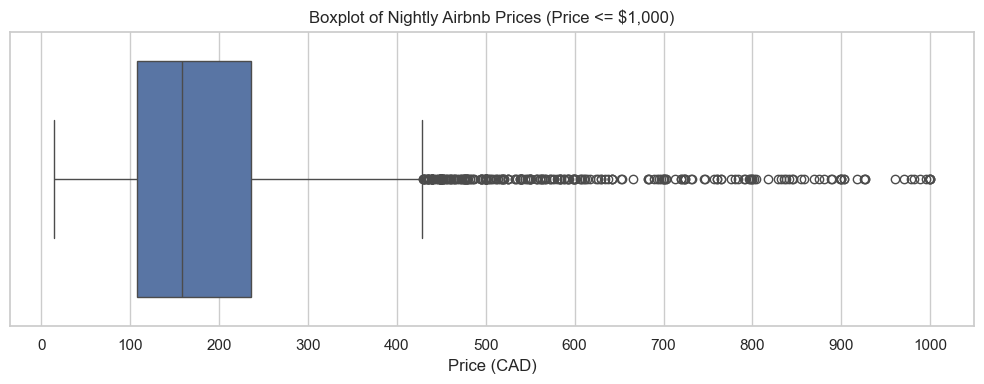

In [28]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_clean[df_clean["price"] <= 1000], x="price")
plt.title("Boxplot of Nightly Airbnb Prices (Price <= $1,000)")
plt.xlabel("Price (CAD)")
plt.xticks(range(0,1001,100))
plt.tight_layout()
plt.show()

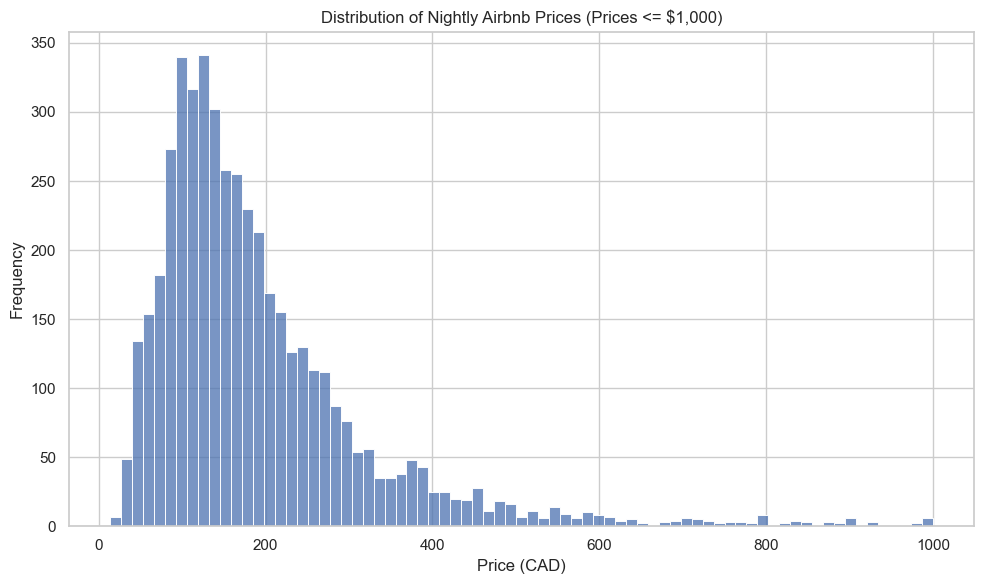

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean[df_clean["price"] <= 1000], x="price", bins=75)
plt.title("Distribution of Nightly Airbnb Prices (Prices <= $1,000)")
plt.xlabel("Price (CAD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Nightly Airbnb prices in Vancouver appear to be strongly right-skewed. The **mean price ($219.76)** is noticeably higher than the **median ($158.00)**, which suggests that a small number of high-price listings are pulling the average upward. The middle 50% of listings lie between **$108.00** and **$239.00**, indicating that most listings are priced far below the maximum.

The distribution also shows substantial variability, with prices ranging from **$14.00** to **$40,896.00** and a **standard deviation of $650.23**. The extremely high maximum strongly suggests the presence of major outliers, so the next section will examine these values more carefully before moving to estimation. The proposal already anticipated the need to handle outliers in the real-data analysis.

### 9. Outlier Inspection

The previous section showed that the nightly price variable is highly right-skewed and contains extremely large values. Because the main parameter of interest in this project is the mean nightly price, unusually high listings may have a substantial influence on the final estimate. For this reason, this section examines extreme price values more closely and assesses how sensitive the data summary is to potential outliers.

The goal is not to remove observations automatically, but to identify unusually large values, inspect whether they appear plausible, and decide how outliers should be handled in the later estimation stage. The project proposal also notes that outliers will need to be addressed in the real data analysis.

In [30]:
top_price_listings = (
    df_clean.sort_values("price", ascending=False)[
        ["id", "neighbourhood", "room_type", "property_type", "accommodates", "bedrooms", "bathrooms", "number_of_reviews", "price"]
    ]
    .head(10)
)

top_price_listings

,id,neighbourhood,room_type,property_type,accommodates,bedrooms,bathrooms,number_of_reviews,price
3489,1297877928269840869,Downtown,Entire home/apt,Entire rental unit,4,2.00,1.00,14,"40,896.00"
1936,805964097745033311,Downtown,Entire home/apt,Entire rental unit,2,1.00,1.00,99,"5,652.00"
3470,1294357174250535150,Downtown,Entire home/apt,Entire rental unit,4,2.00,1.00,5,"5,469.00"
3477,1295694319534464167,Downtown Eastside,Entire home/apt,Entire rental unit,2,1.00,1.00,7,"5,365.00"
2658,1044219470084585888,Downtown,Entire home/apt,Entire rental unit,8,4.00,6.50,0,"5,000.00"
2659,1044225940299262990,Downtown,Entire home/apt,Entire rental unit,8,4.00,5.00,0,"5,000.00"
1372,54267743,Downtown,Private room,Private room in condo,2,1.00,1.00,181,"4,269.00"
249,12336968,Kensington-Cedar Cottage,Entire home/apt,Entire home,11,5.00,3.00,79,"3,325.00"
1118,48082323,Fairview,Entire home/apt,Entire townhouse,6,3.00,2.00,74,"3,261.00"
3496,1298791627605054469,Downtown,Entire home/apt,Entire rental unit,2,1.00,1.00,11,"2,888.00"


In [31]:
q1 = df_clean["price"].quantile(0.25)
q3 = df_clean["price"].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Lower fence: {lower_fence:.2f}")
print(f"Upper fence: {upper_fence:.2f}")

Q1: 108.00
Q3: 239.00
IQR: 131.00
Lower fence: -88.50
Upper fence: 435.50


In [32]:
df_clean["price_outlier_iqr"] = (
    (df_clean["price"] < lower_fence) | (df_clean["price"] > upper_fence)
)

outlier_count = df_clean["price_outlier_iqr"].sum()
outlier_pct = df_clean["price_outlier_iqr"].mean() * 100

print("Number of IQR outliers:", outlier_count)
print(f"Percent of listings flagged: {outlier_pct:.2f}%")

Number of IQR outliers: 297
Percent of listings flagged: 6.31%


In [33]:
upper_outliers = df_clean.loc[
    df_clean["price"] > upper_fence,
    ["id", "neighbourhood", "room_type", "property_type", "accommodates", "bedrooms", "bathrooms", "number_of_reviews", "price"]
].sort_values("price", ascending=False)

upper_outliers.head(20)

,id,neighbourhood,room_type,property_type,accommodates,bedrooms,bathrooms,number_of_reviews,price
3489,1297877928269840869,Downtown,Entire home/apt,Entire rental unit,4,2.00,1.00,14,"40,896.00"
1936,805964097745033311,Downtown,Entire home/apt,Entire rental unit,2,1.00,1.00,99,"5,652.00"
3470,1294357174250535150,Downtown,Entire home/apt,Entire rental unit,4,2.00,1.00,5,"5,469.00"
3477,1295694319534464167,Downtown Eastside,Entire home/apt,Entire rental unit,2,1.00,1.00,7,"5,365.00"
2659,1044225940299262990,Downtown,Entire home/apt,Entire rental unit,8,4.00,5.00,0,"5,000.00"
2658,1044219470084585888,Downtown,Entire home/apt,Entire rental unit,8,4.00,6.50,0,"5,000.00"
1372,54267743,Downtown,Private room,Private room in condo,2,1.00,1.00,181,"4,269.00"
249,12336968,Kensington-Cedar Cottage,Entire home/apt,Entire home,11,5.00,3.00,79,"3,325.00"
1118,48082323,Fairview,Entire home/apt,Entire townhouse,6,3.00,2.00,74,"3,261.00"
3496,1298791627605054469,Downtown,Entire home/apt,Entire rental unit,2,1.00,1.00,11,"2,888.00"


In [34]:
price_compare = pd.DataFrame({
    "Full data": df_clean["price"].describe(),
    "Without IQR outliers": df_clean.loc[~df_clean["price_outlier_iqr"], "price"].describe()
})

price_compare

,Full data,Without IQR outliers
count,"4,702.00","4,405.00"
mean,219.76,169.14
std,650.23,86.23
min,14.00,14.00
25%,108.00,105.00
50%,158.00,150.00
75%,239.00,218.00
max,"40,896.00",435.00


In [35]:
comparison_stats = pd.DataFrame({
    "Dataset": ["Full data", "Without IQR outliers"],
    "Mean": [
        df_clean["price"].mean(),
        df_clean.loc[~df_clean["price_outlier_iqr"], "price"].mean()
    ],
    "Median": [
        df_clean["price"].median(),
        df_clean.loc[~df_clean["price_outlier_iqr"], "price"].median()
    ],
    "Std Dev": [
        df_clean["price"].std(),
        df_clean.loc[~df_clean["price_outlier_iqr"], "price"].std()
    ],
    "Max": [
        df_clean["price"].max(),
        df_clean.loc[~df_clean["price_outlier_iqr"], "price"].max()
    ]
})

comparison_stats

,Dataset,Mean,Median,Std Dev,Max
0,Full data,219.76,158.00,650.23,"40,896.00"
1,Without IQR outliers,169.14,150.00,86.23,435.00


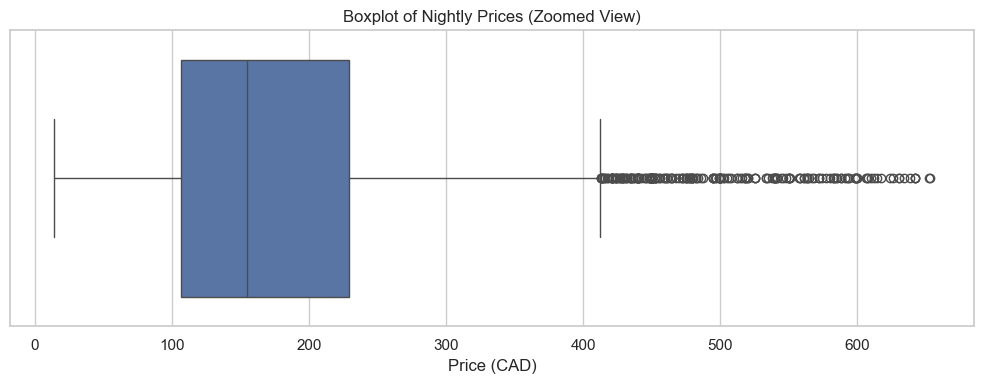

In [36]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_clean[df_clean["price"] <= upper_fence * 1.5], x="price")
plt.title("Boxplot of Nightly Prices (Zoomed View)")
plt.xlabel("Price (CAD)")
plt.tight_layout()
plt.show()

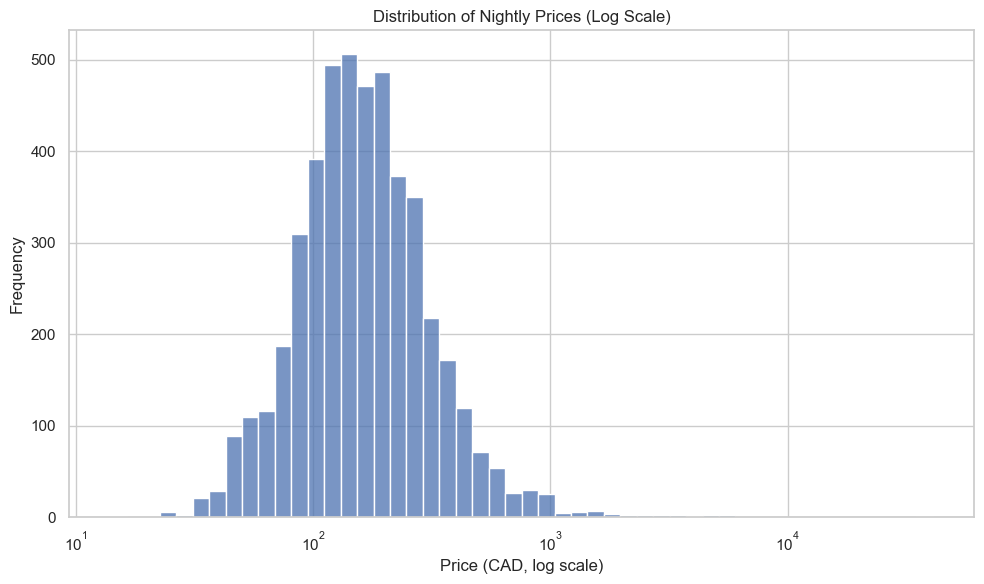

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean["price"], bins=50, log_scale=True)
plt.title("Distribution of Nightly Prices (Log Scale)")
plt.xlabel("Price (CAD, log scale)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The outlier analysis shows that nightly Airbnb prices have a substantial upper tail. Based on the IQR rule, listings above **$435.50** are flagged as outliers, resulting in **297 flagged listings (6.31%)**. Many of the most extreme listings are located in **Downtown** and are primarily **entire home/apartment** properties.

These outliers have a strong effect on the mean. The average price drops from **$219.76** in the full data to **$169.14** after excluding IQR outliers, while the median changes only slightly from **$158.00** to **$150.00**. This indicates that a relatively small number of very expensive listings are pulling the mean upward. The most extreme case, priced at **$40,896**, appears especially suspicious and should be examined carefully in the later analysis.

**No Action for Now**:
At the EDA stage, extreme prices are identified and documented, but not removed automatically. A sensitivity analysis will be conducted later, after the main sampling estimators are applied, to evaluate how much the final results depend on these upper-tail observations.

### 10. Neighbourhood Structure

Neighbourhood is a central variable in this project because it can be used as a stratification variable for the later sampling analysis. Before implementing stratified sampling, it is important to understand how listings are distributed across neighbourhoods and whether the potential strata are reasonably sized.

This section examines the number of listings in each neighbourhood, the relative size of each stratum, and whether any neighbourhoods are very small. These checks help determine whether neighbourhood is a practical and informative basis for stratified sampling in the later stages of the project.

In [38]:
n_neighbourhoods = df_clean["neighbourhood"].nunique()
print("Number of distinct neighbourhoods:", n_neighbourhoods)

Number of distinct neighbourhoods: 23


In [39]:
neighbourhood_counts = (
    df_clean["neighbourhood"]
    .value_counts()
    .rename_axis("neighbourhood")
    .reset_index(name="listing_count")
)

neighbourhood_counts["percent_of_listings"] = (
    neighbourhood_counts["listing_count"] / len(df_clean) * 100
)

neighbourhood_counts.head(15)

,neighbourhood,listing_count,percent_of_listings
0,Downtown,1183,25.14
1,Kitsilano,321,6.82
2,Mount Pleasant,306,6.50
3,Downtown Eastside,297,6.31
4,Hastings-Sunrise,268,5.70
5,West End,265,5.63
6,Kensington-Cedar Cottage,254,5.40
7,Riley Park,204,4.34
8,Renfrew-Collingwood,204,4.34
9,Dunbar Southlands,171,3.63


In [40]:
print("Largest neighbourhood strata:")
display(neighbourhood_counts.head(10))

print("\nSmallest neighbourhood strata:")
display(neighbourhood_counts.tail(10))

Largest neighbourhood strata:


,neighbourhood,listing_count,percent_of_listings
0,Downtown,1183,25.14
1,Kitsilano,321,6.82
2,Mount Pleasant,306,6.50
3,Downtown Eastside,297,6.31
4,Hastings-Sunrise,268,5.70
5,West End,265,5.63
6,Kensington-Cedar Cottage,254,5.40
7,Riley Park,204,4.34
8,Renfrew-Collingwood,204,4.34
9,Dunbar Southlands,171,3.63



Smallest neighbourhood strata:


,neighbourhood,listing_count,percent_of_listings
13,Sunset,125,2.66
14,Fairview,114,2.42
15,Arbutus Ridge,108,2.30
16,West Point Grey,107,2.27
17,Oakridge,70,1.49
18,Killarney,69,1.47
19,Shaughnessy,69,1.47
20,Kerrisdale,57,1.21
21,South Cambie,38,0.81
22,Strathcona,19,0.40


In [41]:
small_strata = neighbourhood_counts[neighbourhood_counts["listing_count"] < 20]
small_strata

,neighbourhood,listing_count,percent_of_listings
22,Strathcona,19,0.40


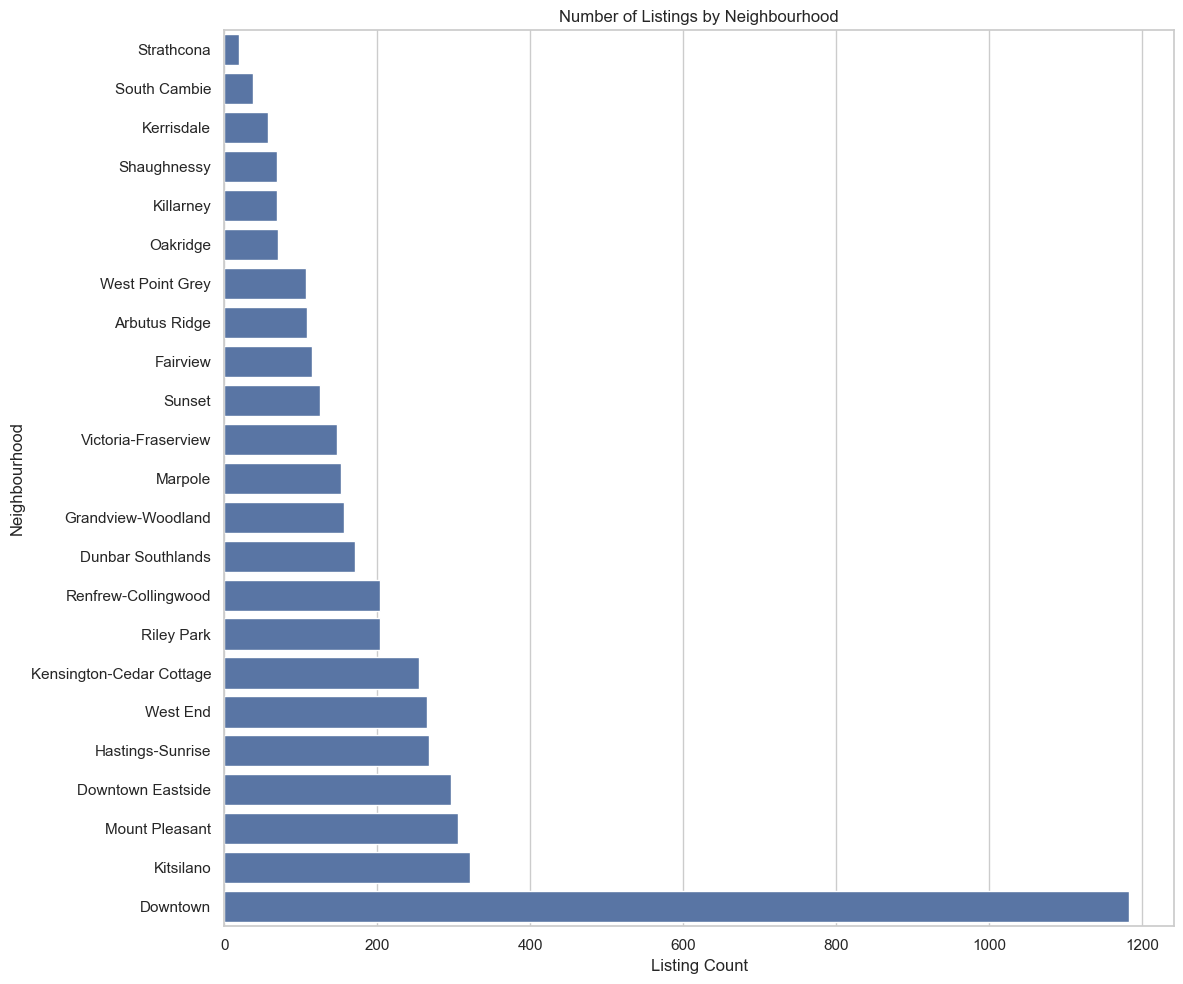

In [42]:
plot_df = neighbourhood_counts.sort_values("listing_count", ascending=True)

plt.figure(figsize=(12, 10))
sns.barplot(data=plot_df, y="neighbourhood", x="listing_count")
plt.title("Number of Listings by Neighbourhood")
plt.xlabel("Listing Count")
plt.ylabel("Neighbourhood")
plt.tight_layout()
plt.show()

In [43]:
top5_share = neighbourhood_counts.head(5)["listing_count"].sum() / len(df_clean) * 100
top10_share = neighbourhood_counts.head(10)["listing_count"].sum() / len(df_clean) * 100

print(f"Top 5 neighbourhoods account for {top5_share:.2f}% of listings.")
print(f"Top 10 neighbourhoods account for {top10_share:.2f}% of listings.")

Top 5 neighbourhoods account for 50.48% of listings.
Top 10 neighbourhoods account for 73.82% of listings.


The cleaned dataset contains **23 neighbourhoods**, but listings are not evenly distributed across them. **Downtown dominates the dataset with 25.14% of all listings**, while most other neighbourhoods contain much smaller shares. The **top 5 neighbourhoods account for 50.48% of listings**, and the **top 10 account for 73.82%**, showing that Airbnb activity is heavily concentrated in a relatively small number of areas.

At the same time, a few neighbourhoods have very small strata, most notably **Strathcona with only 19 listings**. This is important for later stratified sampling, since very small strata may lead to limited sample sizes and less stable neighbourhood-level estimates. Overall, however, neighbourhood still appears to be a strong and practical stratification variable for the project.

### 11. Price by Neighbourhood

A central goal of this project is to examine how Airbnb prices vary across Vancouver neighbourhoods. I plan to use neighbourhood as the stratification variable for the later sampling analysis, so it is important to understand whether there are meaningful price differences across strata. 

This section summarizes nightly prices by neighbourhood using descriptive statistics and visualizations. The purpose is to identify the most and least expensive neighbourhoods, assess the variability of prices within neighbourhoods, and evaluate whether neighbourhood appears to be a strong basis for stratified sampling.


In [44]:
price_by_neighbourhood = (
    df_clean.groupby("neighbourhood")["price"]
    .agg(
        listing_count="count",
        mean_price="mean",
        median_price="median",
        std_price="std",
        min_price="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max_price="max"
    )
    .sort_values("mean_price", ascending=False)
    .reset_index()
)

price_by_neighbourhood

,neighbourhood,listing_count,mean_price,median_price,std_price,min_price,q1,q3,max_price
0,Downtown,1180,300.44,205.00,"1,241.83",25.00,150.00,275.25,"40,896.00"
1,Kerrisdale,57,257.74,139.00,336.85,62.00,101.00,238.00,"1,913.00"
2,Kitsilano,321,242.94,187.00,243.39,37.00,110.00,280.00,"2,800.00"
3,Arbutus Ridge,108,242.27,158.00,242.03,54.00,109.25,269.50,"1,612.00"
4,Downtown Eastside,297,231.64,185.00,320.13,51.00,149.00,252.00,"5,365.00"
5,Oakridge,70,225.04,120.50,294.12,39.00,88.25,232.00,"1,605.00"
6,West End,265,217.33,160.00,193.41,66.00,110.00,251.00,"2,238.00"
7,South Cambie,38,213.76,170.50,134.64,44.00,149.50,233.75,700.00
8,Shaughnessy,69,212.99,149.00,223.85,48.00,101.00,214.00,"1,350.00"
9,Fairview,114,209.25,125.00,327.20,74.00,95.75,198.25,"3,261.00"


In [45]:
print("Most expensive neighbourhoods by mean price:")
display(price_by_neighbourhood.head(10))

print("\nLeast expensive neighbourhoods by mean price:")
display(price_by_neighbourhood.tail(10))

Most expensive neighbourhoods by mean price:


,neighbourhood,listing_count,mean_price,median_price,std_price,min_price,q1,q3,max_price
0,Downtown,1180,300.44,205.00,"1,241.83",25.00,150.00,275.25,"40,896.00"
1,Kerrisdale,57,257.74,139.00,336.85,62.00,101.00,238.00,"1,913.00"
2,Kitsilano,321,242.94,187.00,243.39,37.00,110.00,280.00,"2,800.00"
3,Arbutus Ridge,108,242.27,158.00,242.03,54.00,109.25,269.50,"1,612.00"
4,Downtown Eastside,297,231.64,185.00,320.13,51.00,149.00,252.00,"5,365.00"
5,Oakridge,70,225.04,120.50,294.12,39.00,88.25,232.00,"1,605.00"
6,West End,265,217.33,160.00,193.41,66.00,110.00,251.00,"2,238.00"
7,South Cambie,38,213.76,170.50,134.64,44.00,149.50,233.75,700.00
8,Shaughnessy,69,212.99,149.00,223.85,48.00,101.00,214.00,"1,350.00"
9,Fairview,114,209.25,125.00,327.20,74.00,95.75,198.25,"3,261.00"



Least expensive neighbourhoods by mean price:


,neighbourhood,listing_count,mean_price,median_price,std_price,min_price,q1,q3,max_price
13,Kensington-Cedar Cottage,254,193.03,136.00,278.28,32.00,100.50,186.00,"3,325.00"
14,Grandview-Woodland,157,179.57,135.00,191.43,50.00,98.00,192.00,"2,183.00"
15,Dunbar Southlands,171,173.77,133.00,146.84,42.00,90.00,185.00,960.00
16,Strathcona,19,170.84,183.00,56.97,79.00,118.00,210.50,255.00
17,Mount Pleasant,306,165.52,132.50,126.44,32.00,95.50,194.25,970.00
18,Sunset,125,162.10,128.00,121.06,48.00,95.00,183.00,799.00
19,Hastings-Sunrise,268,156.36,120.50,127.07,30.00,79.75,182.50,995.00
20,Victoria-Fraserview,147,145.67,120.00,82.69,34.00,92.50,180.00,563.00
21,Renfrew-Collingwood,204,141.92,122.50,88.33,14.00,90.75,170.00,642.00
22,Marpole,152,140.85,122.00,94.29,36.00,81.75,161.75,572.00


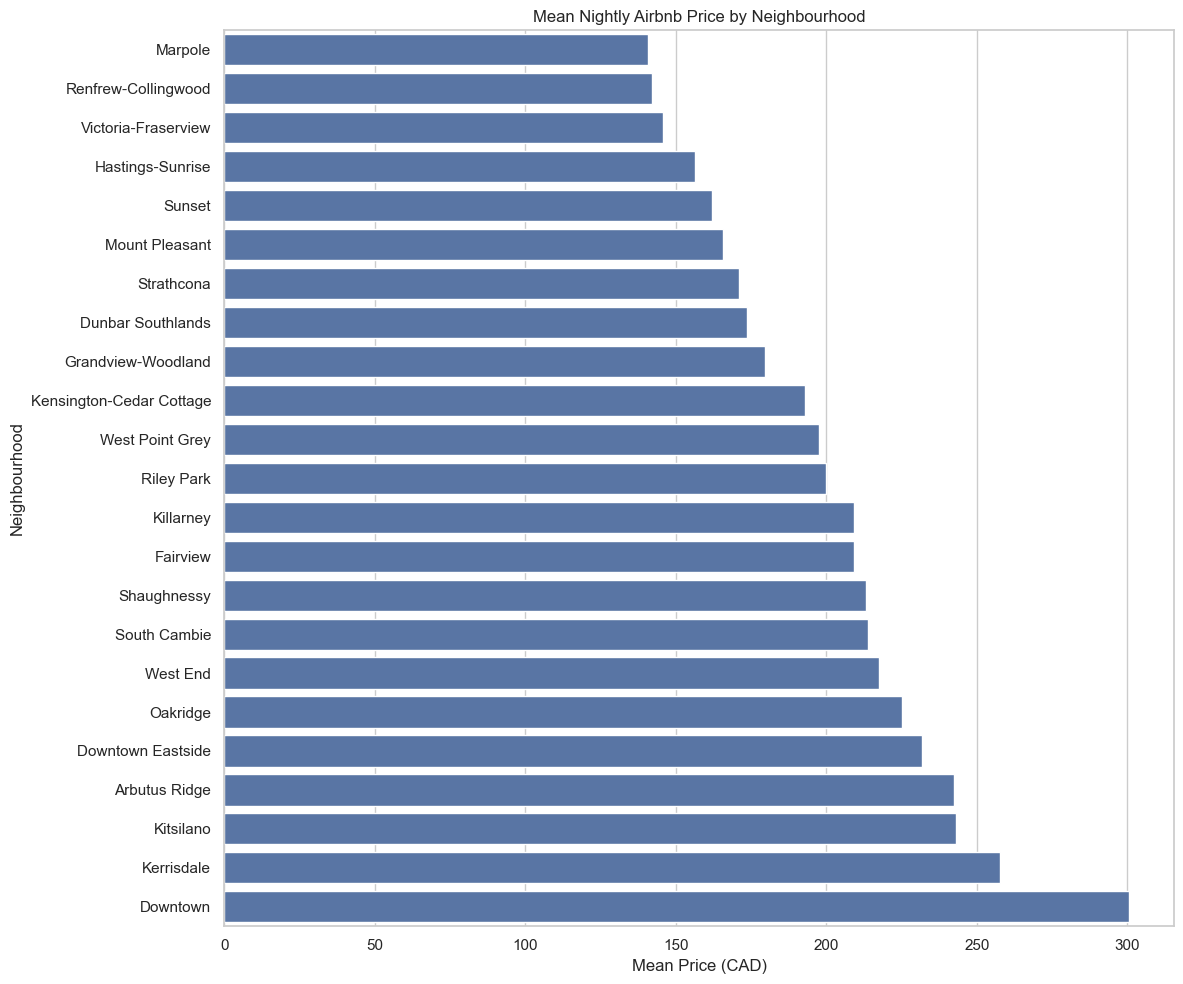

In [46]:
plot_df = price_by_neighbourhood.sort_values("mean_price", ascending=True)

plt.figure(figsize=(12, 10))
sns.barplot(data=plot_df, y="neighbourhood", x="mean_price")
plt.title("Mean Nightly Airbnb Price by Neighbourhood")
plt.xlabel("Mean Price (CAD)")
plt.ylabel("Neighbourhood")
plt.tight_layout()
plt.show()

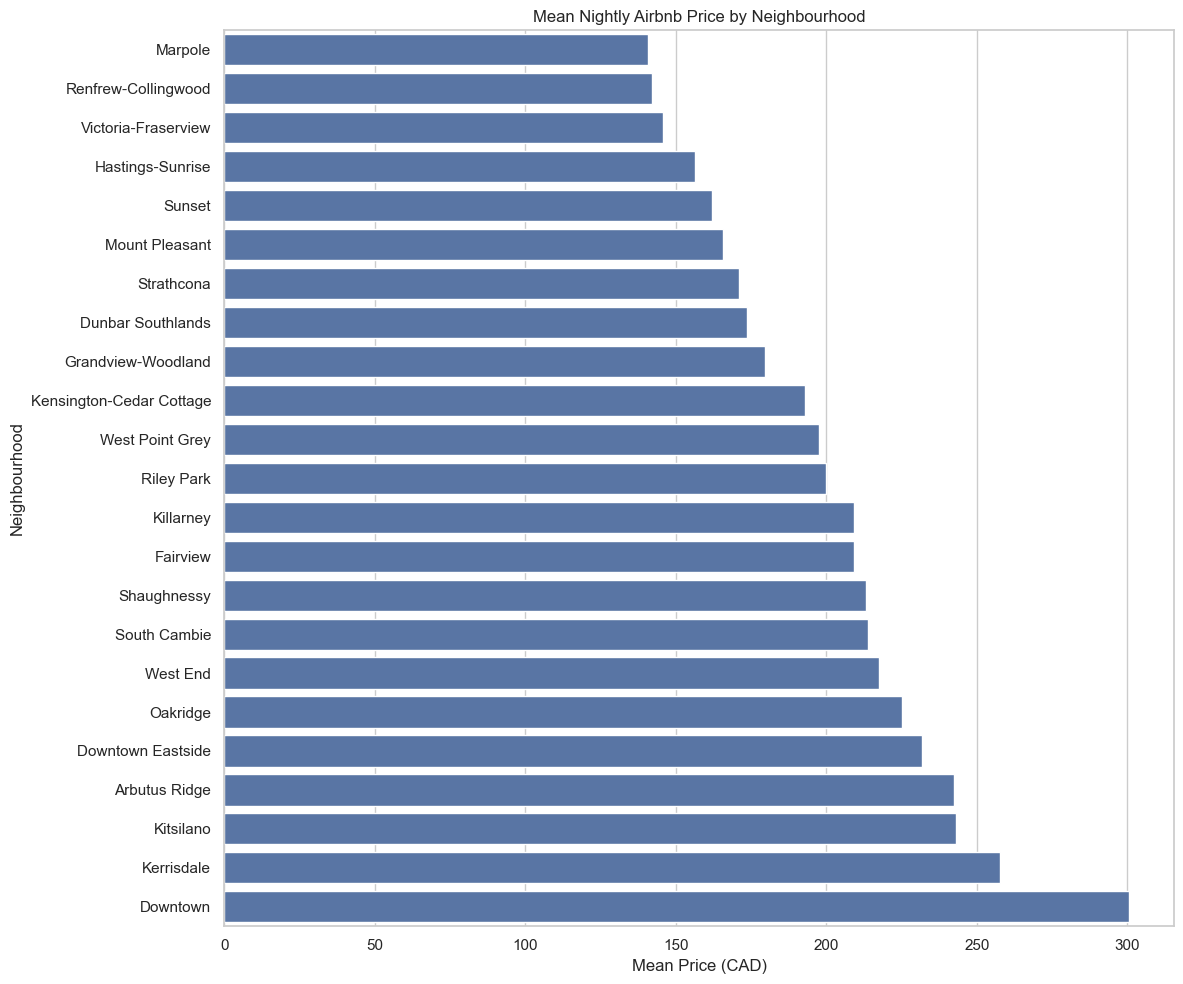

In [47]:
plot_df = price_by_neighbourhood.sort_values("mean_price", ascending=True)

plt.figure(figsize=(12, 10))
sns.barplot(data=plot_df, y="neighbourhood", x="mean_price")
plt.title("Mean Nightly Airbnb Price by Neighbourhood")
plt.xlabel("Mean Price (CAD)")
plt.ylabel("Neighbourhood")
plt.tight_layout()
plt.show()

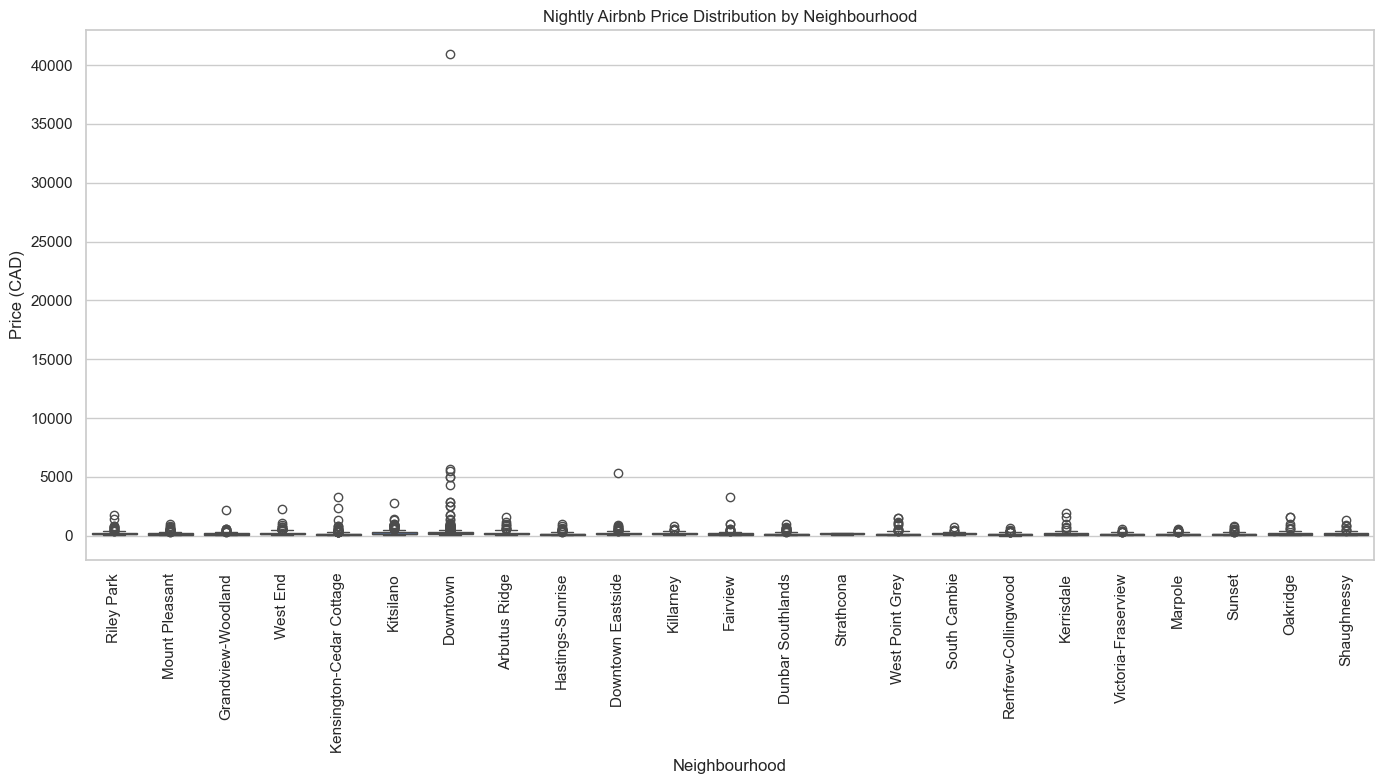

In [48]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_clean, x="neighbourhood", y="price")
plt.xticks(rotation=90)
plt.title("Nightly Airbnb Price Distribution by Neighbourhood")
plt.xlabel("Neighbourhood")
plt.ylabel("Price (CAD)")
plt.tight_layout()
plt.show()

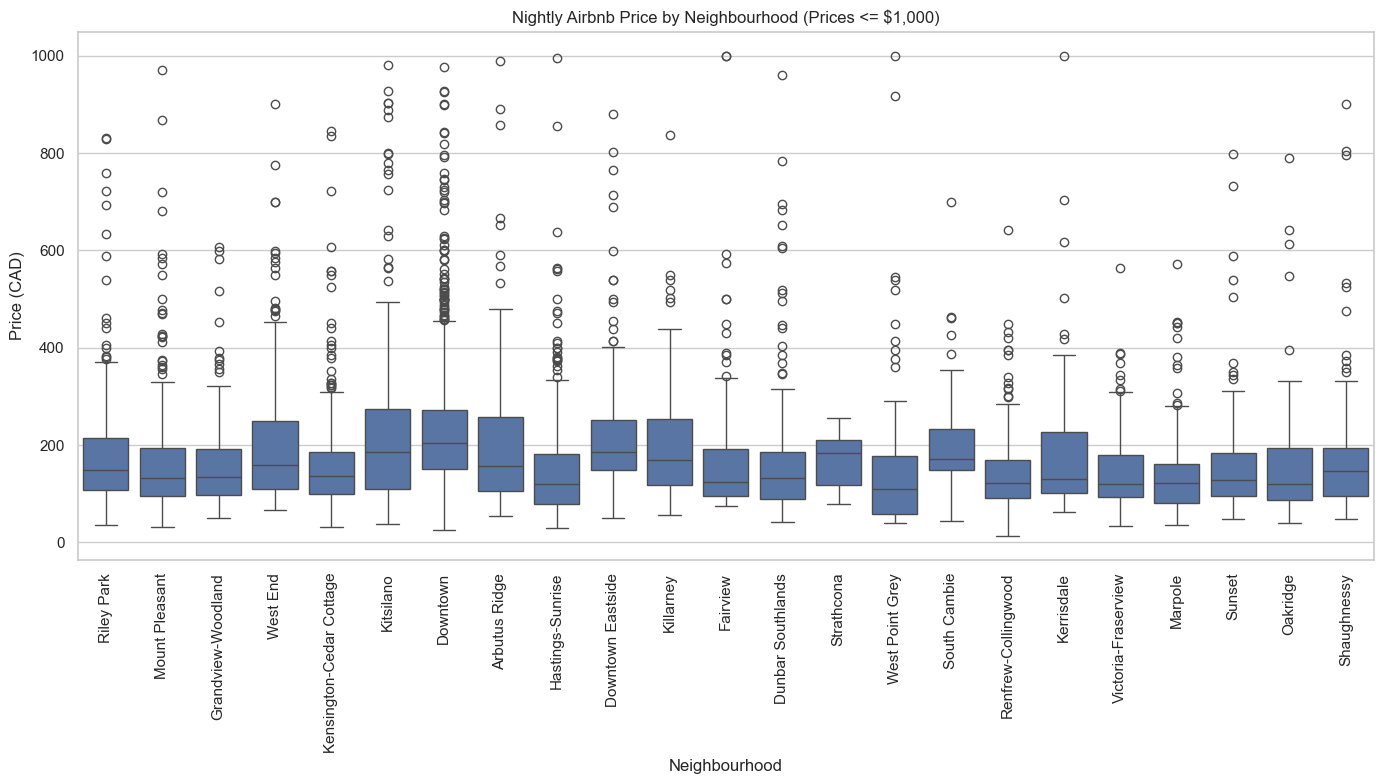

In [50]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_clean[df_clean["price"] <= 1000], x="neighbourhood", y="price")
plt.xticks(rotation=90)
plt.title("Nightly Airbnb Price by Neighbourhood (Prices <= $1,000)")
plt.xlabel("Neighbourhood")
plt.ylabel("Price (CAD)")
plt.tight_layout()
plt.show()

In [51]:
price_variability = (
    df_clean.groupby("neighbourhood")["price"]
    .agg(listing_count="count", std_price="std")
    .sort_values("std_price", ascending=False)
    .reset_index()
)

price_variability.head(10)

,neighbourhood,listing_count,std_price
0,Downtown,1180,"1,241.83"
1,Kerrisdale,57,336.85
2,Fairview,114,327.20
3,Downtown Eastside,297,320.13
4,Oakridge,70,294.12
5,Kensington-Cedar Cottage,254,278.28
6,West Point Grey,107,270.94
7,Kitsilano,321,243.39
8,Arbutus Ridge,108,242.03
9,Shaughnessy,69,223.85


Airbnb prices vary noticeably across Vancouver neighbourhoods. **Downtown** has the highest mean nightly price at **$300.44**, followed by **Kerrisdale ($257.74)**, **Kitsilano ($242.94)**, and **Arbutus Ridge ($242.27)**, while **Marpole ($140.85)**, **Renfrew-Collingwood ($141.92)**, and **Victoria-Fraserview ($145.67)** are among the least expensive. This indicates that neighbourhood is strongly associated with listing price.

However, several neighbourhood means are influenced by high variability and extreme upper-tail prices. Downtown, in particular, has an exceptionally large standard deviation (**$1,241.83**) and an extreme maximum of **$40,896**, suggesting that its average is inflated by a small number of very expensive listings. Even with that caveat, the overall pattern still shows enough between-neighbourhood price differences to support neighbourhood as a useful stratification variable for the later sampling analysis.

### 12. Room Type Analysis

In addition to neighbourhood, room type is an important descriptive feature of Airbnb listings because it reflects the kind of accommodation being offered, such as an entire home, private room, or shared room. 

This section examines the distribution of listings across room types and summarizes how nightly prices vary by room type. The goal is to provide additional context for the Vancouver Airbnb market and to assess whether room type may help explain some of the overall variation in prices.

In [54]:
room_type_summary = (
    df_clean["room_type"]
    .value_counts()
    .rename_axis("room_type")
    .reset_index(name="listing_count")
)

room_type_summary["percent_of_listings"] = (
    room_type_summary["listing_count"] / len(df_clean) * 100
)

room_type_summary

,room_type,listing_count,percent_of_listings
0,Entire home/apt,3749,79.68
1,Private room,942,20.02
2,Shared room,14,0.30


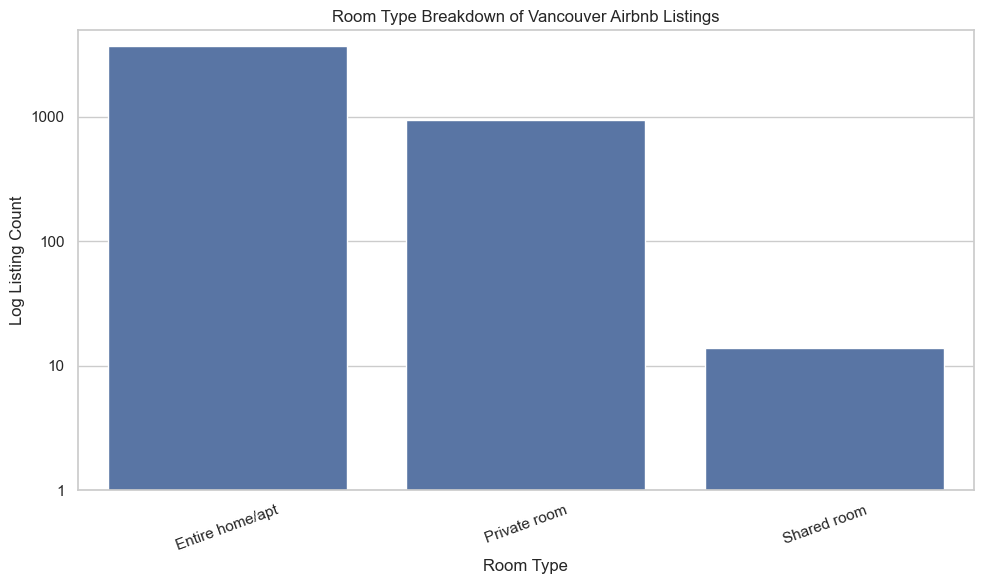

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(data=room_type_summary, x="room_type", y="listing_count")
plt.yscale("log")
plt.title("Room Type Breakdown of Vancouver Airbnb Listings")
plt.xlabel("Room Type")
plt.ylabel("Log Listing Count")
plt.xticks(rotation=20)
plt.yticks([1, 10, 100, 1000], ["1", "10", "100", "1000"])
plt.tight_layout()
plt.show()

In [66]:
price_by_room_type = (
    df_clean.groupby("room_type")["price"]
    .agg(
        listing_count="count",
        mean_price="mean",
        median_price="median",
        std_price="std",
        min_price="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max_price="max"
    )
    .sort_values("mean_price", ascending=False)
    .reset_index()
)

price_by_room_type

,room_type,listing_count,mean_price,median_price,std_price,min_price,q1,q3,max_price
0,Entire home/apt,3746,248.08,180.00,721.26,14.00,128.00,260.00,"40,896.00"
1,Shared room,14,118.07,77.00,155.95,34.00,73.00,86.00,653.00
2,Private room,942,108.62,82.00,160.49,25.00,58.00,120.00,"4,269.00"


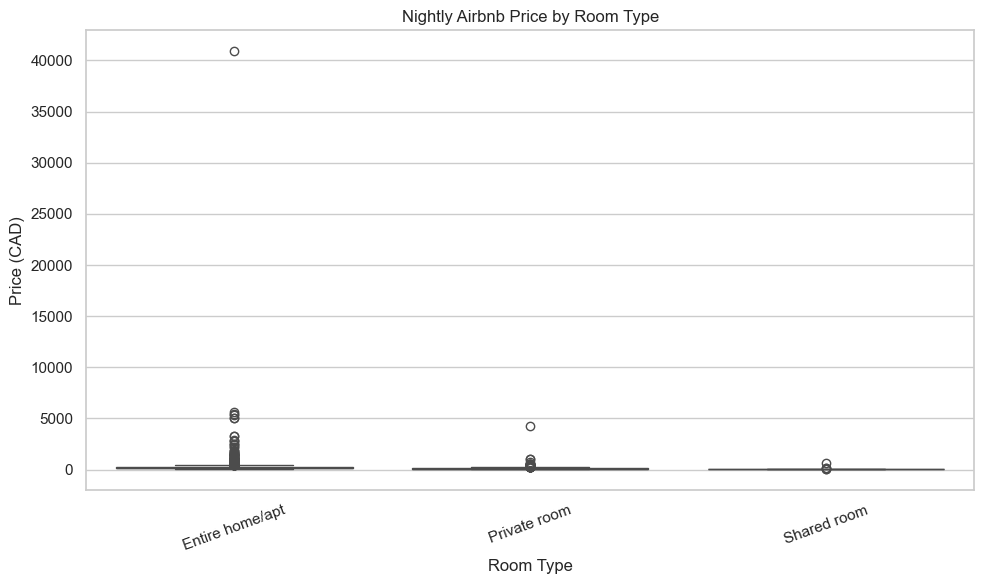

In [67]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="room_type", y="price")
plt.title("Nightly Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price (CAD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

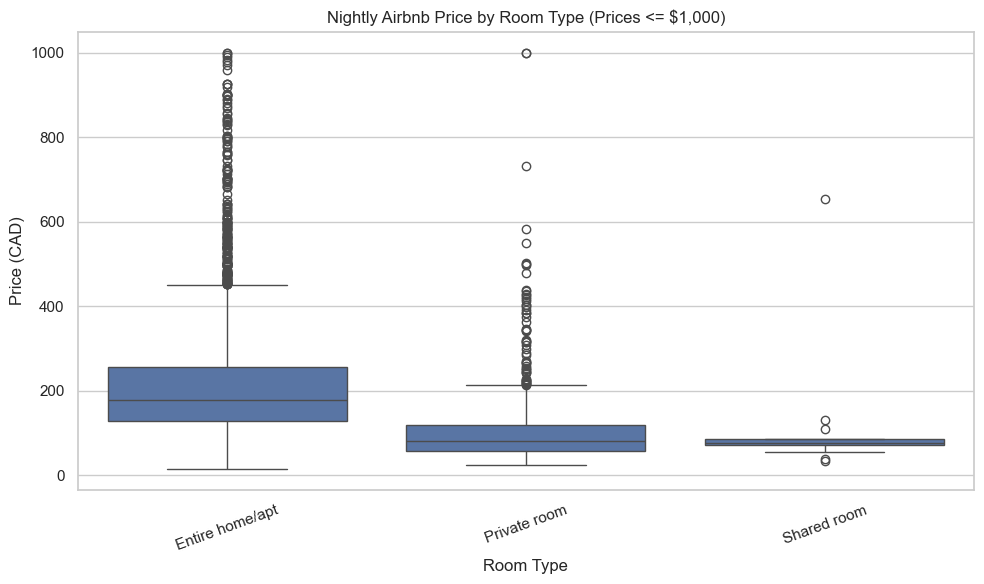

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[df_clean["price"] <= 1000], x="room_type", y="price")
plt.title("Nightly Airbnb Price by Room Type (Prices <= $1,000)")
plt.xlabel("Room Type")
plt.ylabel("Price (CAD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

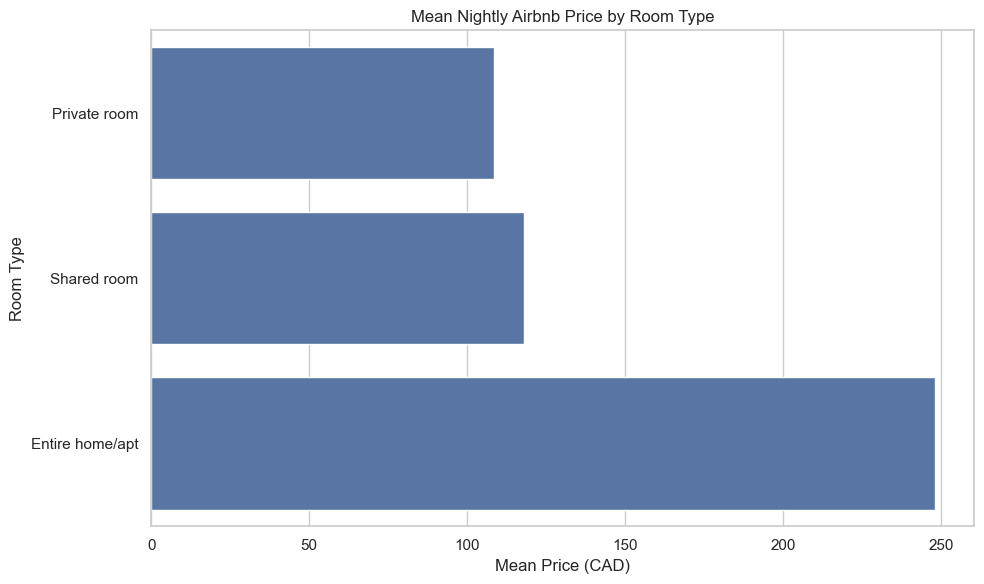

In [69]:
plot_df = price_by_room_type.sort_values("mean_price", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="mean_price", y="room_type")
plt.title("Mean Nightly Airbnb Price by Room Type")
plt.xlabel("Mean Price (CAD)")
plt.ylabel("Room Type")
plt.tight_layout()
plt.show()

The Airbnb market in Vancouver is heavily concentrated in **entire home/apartment** listings, which make up **79.68%** of all observations. **Private rooms** account for **20.02%**, while **shared rooms** are extremely rare at **0.30%**. This suggests that the dataset is dominated by full-unit rentals rather than lower-cost room-based options.

Room type is also strongly related to price. Entire homes/apartments have the highest prices by a wide margin, with a **mean of $248.08** and a **median of $180.00**, compared with **$108.62** and **$82.00** for private rooms. Shared rooms appear cheaper based on the median, but this category has only **14 listings**, so its results are not very stable. Overall, room type appears to explain an important part of the variation in nightly Airbnb prices, although extreme upper-tail prices within entire home/apartment listings still inflate the average.

### 13. Reviews as an Auxiliary Variable

I plan to explore a standalone ratio estimation analysis that uses `number_of_reviews` as the auxiliary variable. Before carrying out that analysis, it is useful to examine the distribution of review counts and explore how they relate to nightly Airbnb prices.

This section summarizes the `number_of_reviews` variable and visually explores its relationship with price. The goal is not to estimate the ratio yet, but to assess whether review activity appears informative enough to support the later ratio estimation step.

In [72]:
review_stats = pd.Series({
    "count": df_clean["number_of_reviews"].count(),
    "mean": df_clean["number_of_reviews"].mean(),
    "median": df_clean["number_of_reviews"].median(),
    "std": df_clean["number_of_reviews"].std(),
    "min": df_clean["number_of_reviews"].min(),
    "q1": df_clean["number_of_reviews"].quantile(0.25),
    "q3": df_clean["number_of_reviews"].quantile(0.75),
    "max": df_clean["number_of_reviews"].max(),
    "iqr": df_clean["number_of_reviews"].quantile(0.75) - df_clean["number_of_reviews"].quantile(0.25)
})

review_stats

count    4,705.00
mean        59.05
median      22.00
std         93.42
min          0.00
q1           3.00
q3          77.00
max      1,122.00
iqr         74.00
dtype: float64

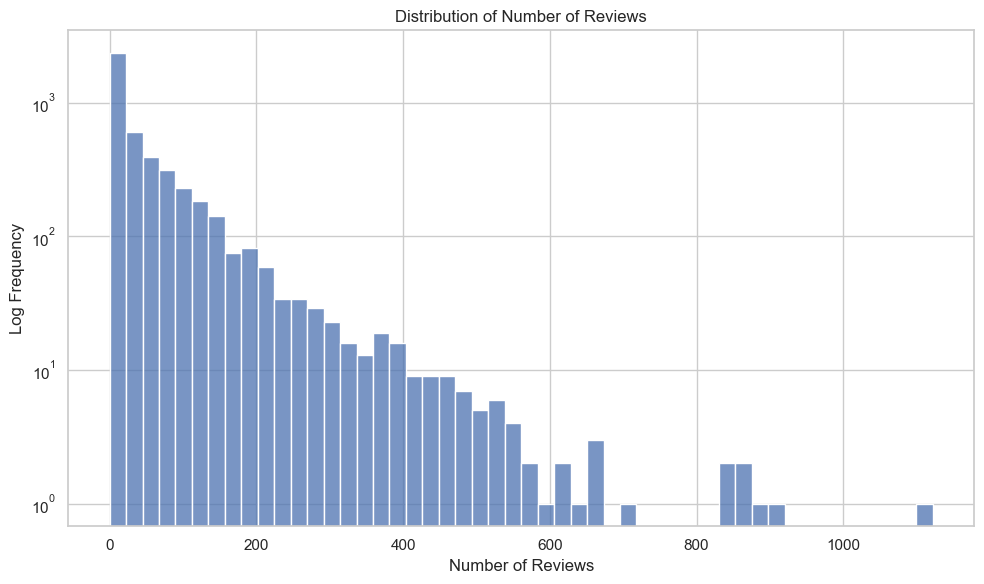

In [80]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x="number_of_reviews", bins=50)
plt.yscale('log')
plt.title("Distribution of Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Log Frequency")
plt.tight_layout()
plt.show()

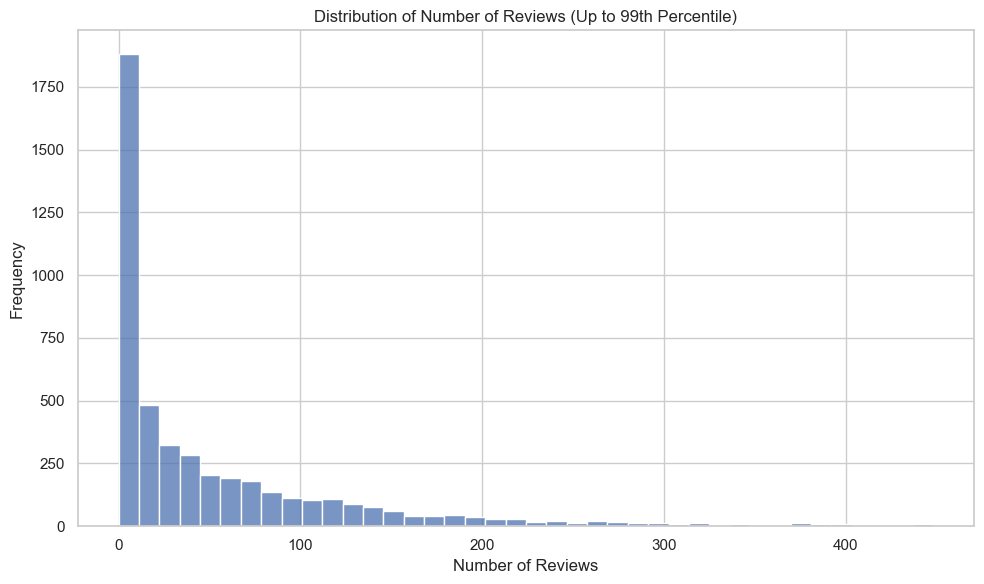

In [74]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean[df_clean["number_of_reviews"] <= df_clean["number_of_reviews"].quantile(0.99)],
             x="number_of_reviews", bins=40)
plt.title("Distribution of Number of Reviews (Up to 99th Percentile)")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

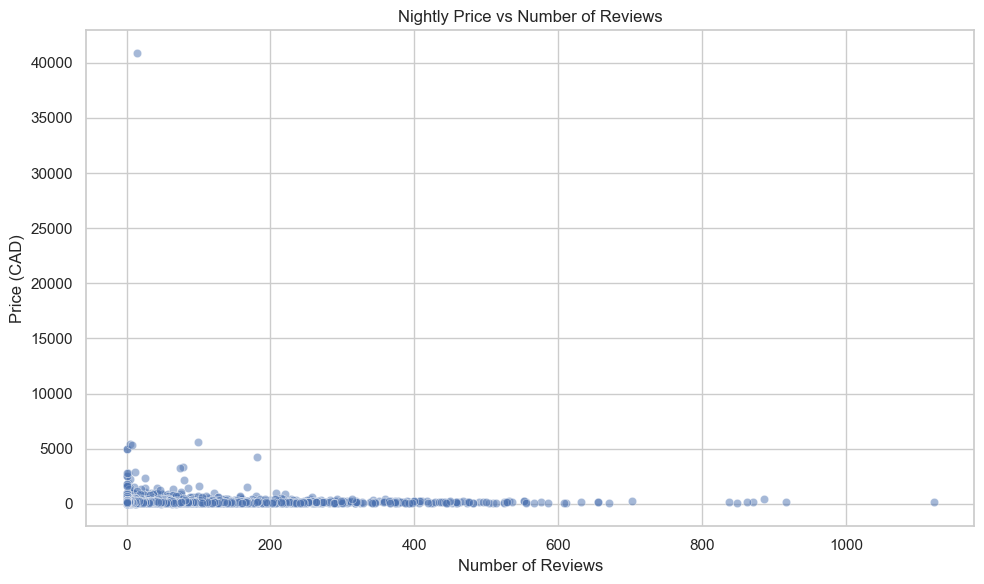

In [76]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="number_of_reviews", y="price", alpha=0.5)
plt.title("Nightly Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (CAD)")
plt.tight_layout()
plt.show()

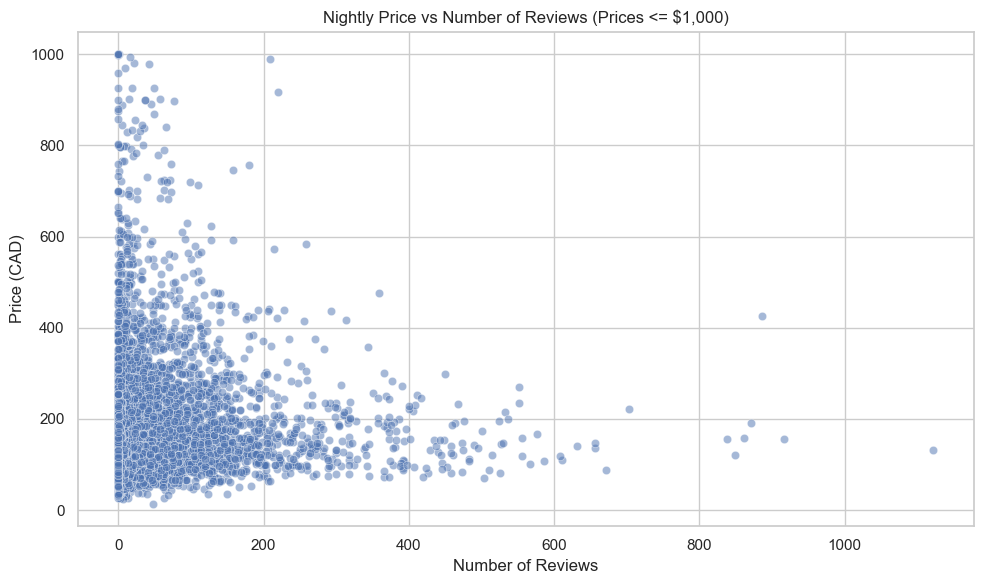

In [77]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean[df_clean["price"] <= 1000],
    x="number_of_reviews",
    y="price",
    alpha=0.5
)
plt.title("Nightly Price vs Number of Reviews (Prices <= $1,000)")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (CAD)")
plt.tight_layout()
plt.show()

In [78]:
corr = df_clean[["price", "number_of_reviews"]].corr().iloc[0, 1]
print(f"Correlation between price and number_of_reviews: {corr:.3f}")

Correlation between price and number_of_reviews: -0.016


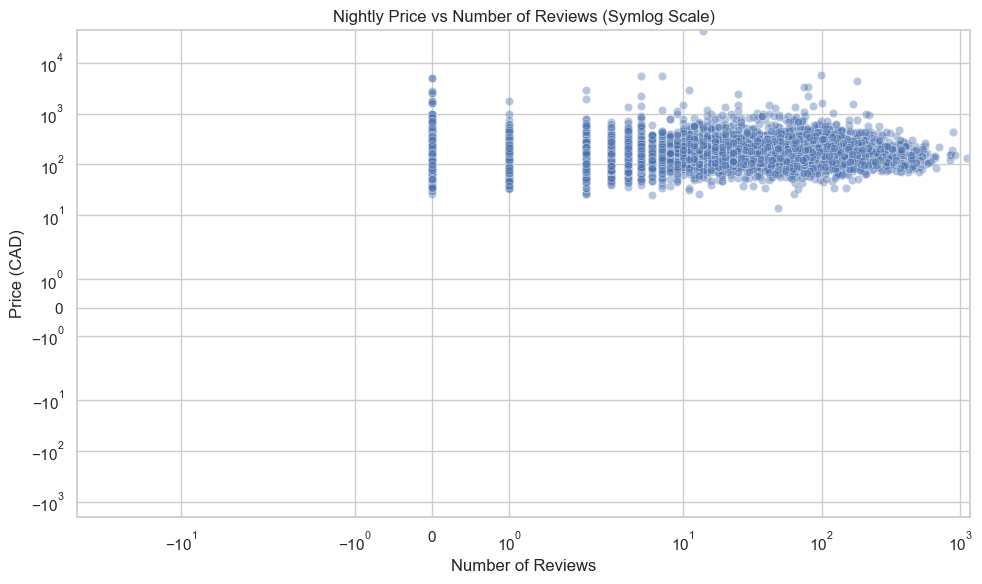

In [79]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="number_of_reviews", y="price", alpha=0.4)
plt.xscale("symlog")
plt.yscale("symlog")
plt.title("Nightly Price vs Number of Reviews (Symlog Scale)")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (CAD)")
plt.tight_layout()
plt.show()

The distribution of `number_of_reviews` is highly right-skewed. The mean review count is **59.05**, but the median is only **22**, showing that most listings have relatively few reviews while a smaller number of listings have very large counts. This pattern is also visible in the histogram, where most observations are concentrated near the lower end and the distribution has a long upper tail up to **1,122 reviews**.

The scatterplots show little evidence of a meaningful relationship between nightly price and review count. This is supported by the correlation of **-0.016**, which is essentially zero. Overall, `number_of_reviews` appears to have only a weak and noisy association with price, so it may still be used for the later ratio estimation analysis, but its usefulness as an auxiliary variable appears limited.

### 14. Create the Analysis Dataset

After examining data quality, missingness, outliers, neighbourhood structure, room types, and review counts, the next step is to define the dataset that will be used for the main sampling analysis. Since nightly price is the primary outcome variable in this project, listings with missing prices cannot be used in the estimation of the population mean and are therefore excluded at this stage.

At the same time, extreme price values are retained for now. The EDA showed that outliers have a noticeable effect on the mean, but they are not removed automatically at this stage because some may represent genuine high-end listings. Instead, a sensitivity analysis will be conducted later after the main sampling results are obtained. This approach keeps the main analysis dataset aligned with the project goal while preserving transparency about the role of extreme observations.


In [82]:
analysis_df = df_clean.dropna(subset=["price"]).copy()
print("Analysis dataset shape:", analysis_df.shape)
print(f"Number of listings in analysis dataset: {len(analysis_df)}")

Analysis dataset shape: (4702, 12)
Number of listings in analysis dataset: 4702


In [83]:
print("Missing prices remaining:", analysis_df["price"].isnull().sum())

Missing prices remaining: 0


In [84]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4702 entries, 0 to 4704
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4702 non-null   int64  
 1   host_id            4702 non-null   int64  
 2   price              4702 non-null   float64
 3   neighbourhood      4702 non-null   object 
 4   room_type          4702 non-null   object 
 5   number_of_reviews  4702 non-null   int64  
 6   property_type      4702 non-null   object 
 7   accommodates       4702 non-null   int64  
 8   bedrooms           4695 non-null   float64
 9   bathrooms          4699 non-null   float64
 10  price_raw          4702 non-null   object 
 11  price_outlier_iqr  4702 non-null   bool   
dtypes: bool(1), float64(3), int64(4), object(4)
memory usage: 445.4+ KB


In [86]:
analysis_df.head()

,id,host_id,price,neighbourhood,room_type,number_of_reviews,property_type,accommodates,bedrooms,bathrooms,price_raw,price_outlier_iqr
0,13188,51466,138.00,Riley Park,Entire home/apt,381,Entire guest suite,4,0.00,1.00,$138.00,False
1,18270,70437,47.00,Mount Pleasant,Private room,118,Private room in condo,2,1.00,1.00,$47.00,False
2,18589,71508,140.00,Grandview-Woodland,Private room,632,Private room in home,2,1.00,1.00,$140.00,False
3,18795,70137,75.00,West End,Private room,131,Private room in home,2,1.00,1.00,$75.00,False
4,20085,75986,136.00,Kensington-Cedar Cottage,Entire home/apt,80,Entire guest suite,3,2.00,1.00,$136.00,False


In [87]:
N = len(analysis_df)
print("Finite population size N =", N)

Finite population size N = 4702


In [88]:
analysis_df.to_csv("analysis_dataset.csv", index=False)

The final analysis dataset contains **4,702 Airbnb listings**, which means only the **3 listings with missing price values** were excluded from the original working dataset. Since the main parameter of interest is the mean nightly price, removing these few incomplete observations is appropriate and results in a clean finite population for the later sampling analysis.

The cleaned dataset is now well structured for the next stage of the project. All core variables needed for estimation are complete, including `price`, `neighbourhood`, `room_type`, `number_of_reviews`, and the listing and host identifiers. This is important because it means the main sampling procedures can be applied without any further missing-data adjustments for the key analysis variables.

A small amount of missingness remains in secondary descriptive variables such as `bedrooms` and `bathrooms`, but this does not affect the main sampling estimators since these variables are not central to estimating the population mean price. In addition, the `price_outlier_iqr` flag has been retained, which is useful because it preserves information about extreme values without removing them at this stage.

Overall, the analysis dataset is now ready for the sampling phase. It provides a clearly defined finite population of **N = 4,702** listings with observed prices, which will be used for the later simple random sampling, stratified sampling, and ratio estimation analyses.

### 15. Sampling Preparation Checks

Before applying the sampling methods, it is useful to compute the key population quantities needed for the later estimation steps. Since the project uses neighbourhood as the stratification variable, this section summarizes the size and variability of each neighbourhood stratum in the final analysis dataset.

These checks are important for both proportional and Neyman allocation. In particular, stratum sizes determine how sample units would be distributed under proportional allocation, while within-stratum standard deviations are needed for Neyman allocation. This section also helps identify whether any neighbourhood strata are very small and may require extra care when interpreting later results.

In [90]:
stratum_summary = (
    analysis_df.groupby("neighbourhood")["price"]
    .agg(
        N_h="count",
        mean_price="mean",
        S_h="std",
        min_price="min",
        max_price="max"
    )
    .reset_index()
)

stratum_summary["W_h"] = stratum_summary["N_h"] / N
stratum_summary = stratum_summary.sort_values("N_h", ascending=False)

stratum_summary

,neighbourhood,N_h,mean_price,S_h,min_price,max_price,W_h
1,Downtown,1180,300.44,"1,241.83",25.00,"40,896.00",0.25
10,Kitsilano,321,242.94,243.39,37.00,"2,800.00",0.07
12,Mount Pleasant,306,165.52,126.44,32.00,970.00,0.07
2,Downtown Eastside,297,231.64,320.13,51.00,"5,365.00",0.06
6,Hastings-Sunrise,268,156.36,127.07,30.00,995.00,0.06
21,West End,265,217.33,193.41,66.00,"2,238.00",0.06
7,Kensington-Cedar Cottage,254,193.03,278.28,32.00,"3,325.00",0.05
15,Riley Park,204,199.90,195.56,35.00,"1,800.00",0.04
14,Renfrew-Collingwood,204,141.92,88.33,14.00,642.00,0.04
3,Dunbar Southlands,171,173.77,146.84,42.00,960.00,0.04


In [91]:
stratum_summary = stratum_summary[
    ["neighbourhood", "N_h", "W_h", "mean_price", "S_h", "min_price", "max_price"]
]

stratum_summary

,neighbourhood,N_h,W_h,mean_price,S_h,min_price,max_price
1,Downtown,1180,0.25,300.44,"1,241.83",25.00,"40,896.00"
10,Kitsilano,321,0.07,242.94,243.39,37.00,"2,800.00"
12,Mount Pleasant,306,0.07,165.52,126.44,32.00,970.00
2,Downtown Eastside,297,0.06,231.64,320.13,51.00,"5,365.00"
6,Hastings-Sunrise,268,0.06,156.36,127.07,30.00,995.00
21,West End,265,0.06,217.33,193.41,66.00,"2,238.00"
7,Kensington-Cedar Cottage,254,0.05,193.03,278.28,32.00,"3,325.00"
15,Riley Park,204,0.04,199.90,195.56,35.00,"1,800.00"
14,Renfrew-Collingwood,204,0.04,141.92,88.33,14.00,642.00
3,Dunbar Southlands,171,0.04,173.77,146.84,42.00,960.00


In [92]:
print("Sum of all stratum sizes:", stratum_summary["N_h"].sum())
print("Matches total N:", stratum_summary["N_h"].sum() == N)

Sum of all stratum sizes: 4702
Matches total N: True


In [94]:
small_strata = stratum_summary[stratum_summary["N_h"] < 30]
print(small_strata)

print("Largest strata:")
display(stratum_summary.sort_values("N_h", ascending=False).head(10))

print("\nSmallest strata:")
display(stratum_summary.sort_values("N_h", ascending=True).head(10))

   neighbourhood  N_h  W_h  mean_price   S_h  min_price  max_price
18    Strathcona   19 0.00      170.84 56.97      79.00     255.00
Largest strata:


,neighbourhood,N_h,W_h,mean_price,S_h,min_price,max_price
1,Downtown,1180,0.25,300.44,"1,241.83",25.00,"40,896.00"
10,Kitsilano,321,0.07,242.94,243.39,37.00,"2,800.00"
12,Mount Pleasant,306,0.07,165.52,126.44,32.00,970.00
2,Downtown Eastside,297,0.06,231.64,320.13,51.00,"5,365.00"
6,Hastings-Sunrise,268,0.06,156.36,127.07,30.00,995.00
21,West End,265,0.06,217.33,193.41,66.00,"2,238.00"
7,Kensington-Cedar Cottage,254,0.05,193.03,278.28,32.00,"3,325.00"
15,Riley Park,204,0.04,199.90,195.56,35.00,"1,800.00"
14,Renfrew-Collingwood,204,0.04,141.92,88.33,14.00,642.00
3,Dunbar Southlands,171,0.04,173.77,146.84,42.00,960.00



Smallest strata:


,neighbourhood,N_h,W_h,mean_price,S_h,min_price,max_price
18,Strathcona,19,0.00,170.84,56.97,79.00,255.00
17,South Cambie,38,0.01,213.76,134.64,44.00,700.00
8,Kerrisdale,57,0.01,257.74,336.85,62.00,"1,913.00"
9,Killarney,69,0.01,209.20,148.39,56.00,838.00
16,Shaughnessy,69,0.01,212.99,223.85,48.00,"1,350.00"
13,Oakridge,70,0.01,225.04,294.12,39.00,"1,605.00"
22,West Point Grey,107,0.02,197.54,270.94,40.00,"1,488.00"
0,Arbutus Ridge,108,0.02,242.27,242.03,54.00,"1,612.00"
4,Fairview,114,0.02,209.25,327.20,74.00,"3,261.00"
19,Sunset,125,0.03,162.10,121.06,48.00,799.00


In [95]:
print("Highest within-stratum variability:")
display(stratum_summary.sort_values("S_h", ascending=False).head(10))

Highest within-stratum variability:


,neighbourhood,N_h,W_h,mean_price,S_h,min_price,max_price
1,Downtown,1180,0.25,300.44,"1,241.83",25.00,"40,896.00"
8,Kerrisdale,57,0.01,257.74,336.85,62.00,"1,913.00"
4,Fairview,114,0.02,209.25,327.20,74.00,"3,261.00"
2,Downtown Eastside,297,0.06,231.64,320.13,51.00,"5,365.00"
13,Oakridge,70,0.01,225.04,294.12,39.00,"1,605.00"
7,Kensington-Cedar Cottage,254,0.05,193.03,278.28,32.00,"3,325.00"
22,West Point Grey,107,0.02,197.54,270.94,40.00,"1,488.00"
10,Kitsilano,321,0.07,242.94,243.39,37.00,"2,800.00"
0,Arbutus Ridge,108,0.02,242.27,242.03,54.00,"1,612.00"
16,Shaughnessy,69,0.01,212.99,223.85,48.00,"1,350.00"


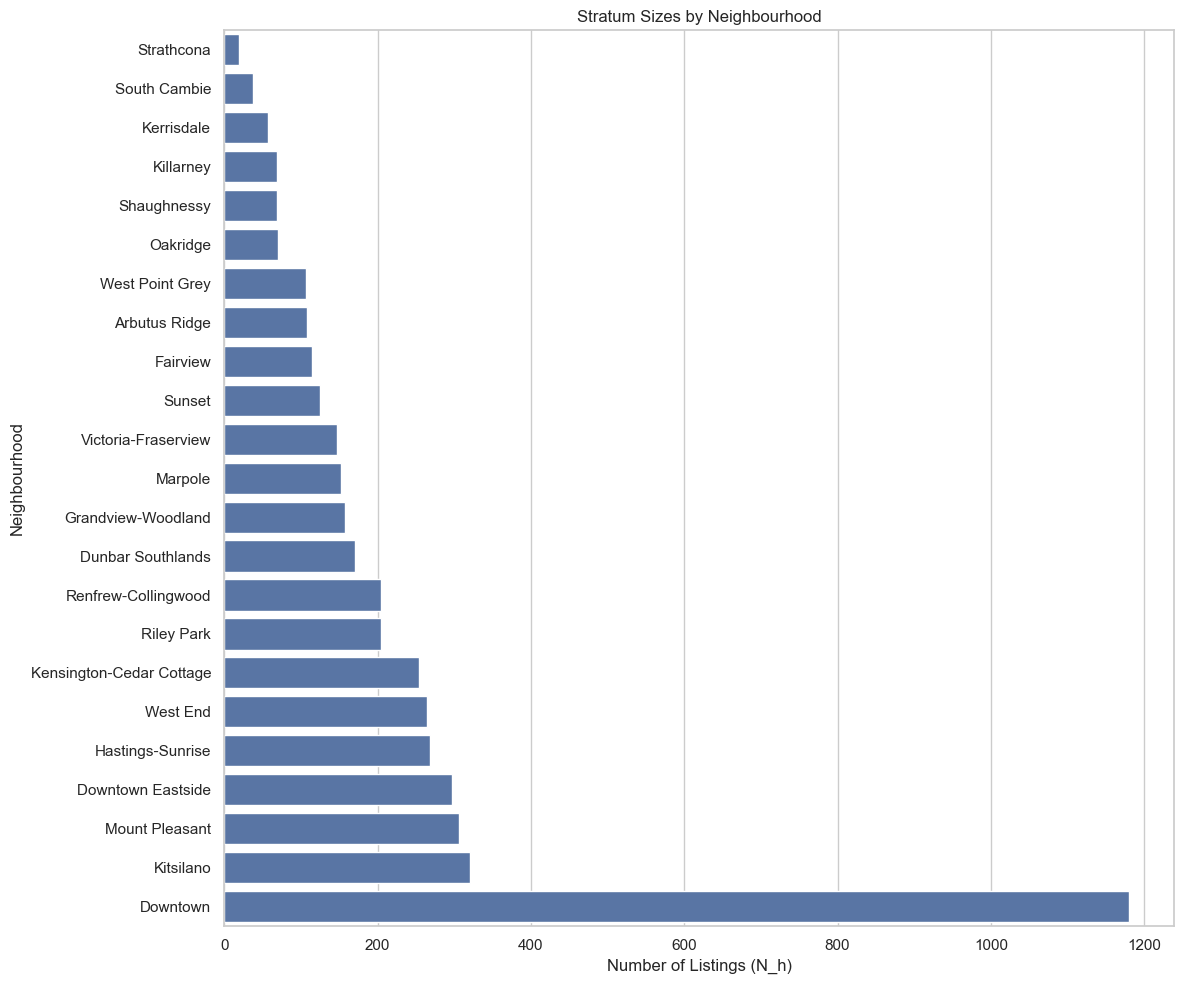

In [96]:
plot_df = stratum_summary.sort_values("N_h", ascending=True)

plt.figure(figsize=(12, 10))
sns.barplot(data=plot_df, y="neighbourhood", x="N_h")
plt.title("Stratum Sizes by Neighbourhood")
plt.xlabel("Number of Listings (N_h)")
plt.ylabel("Neighbourhood")
plt.tight_layout()
plt.show()

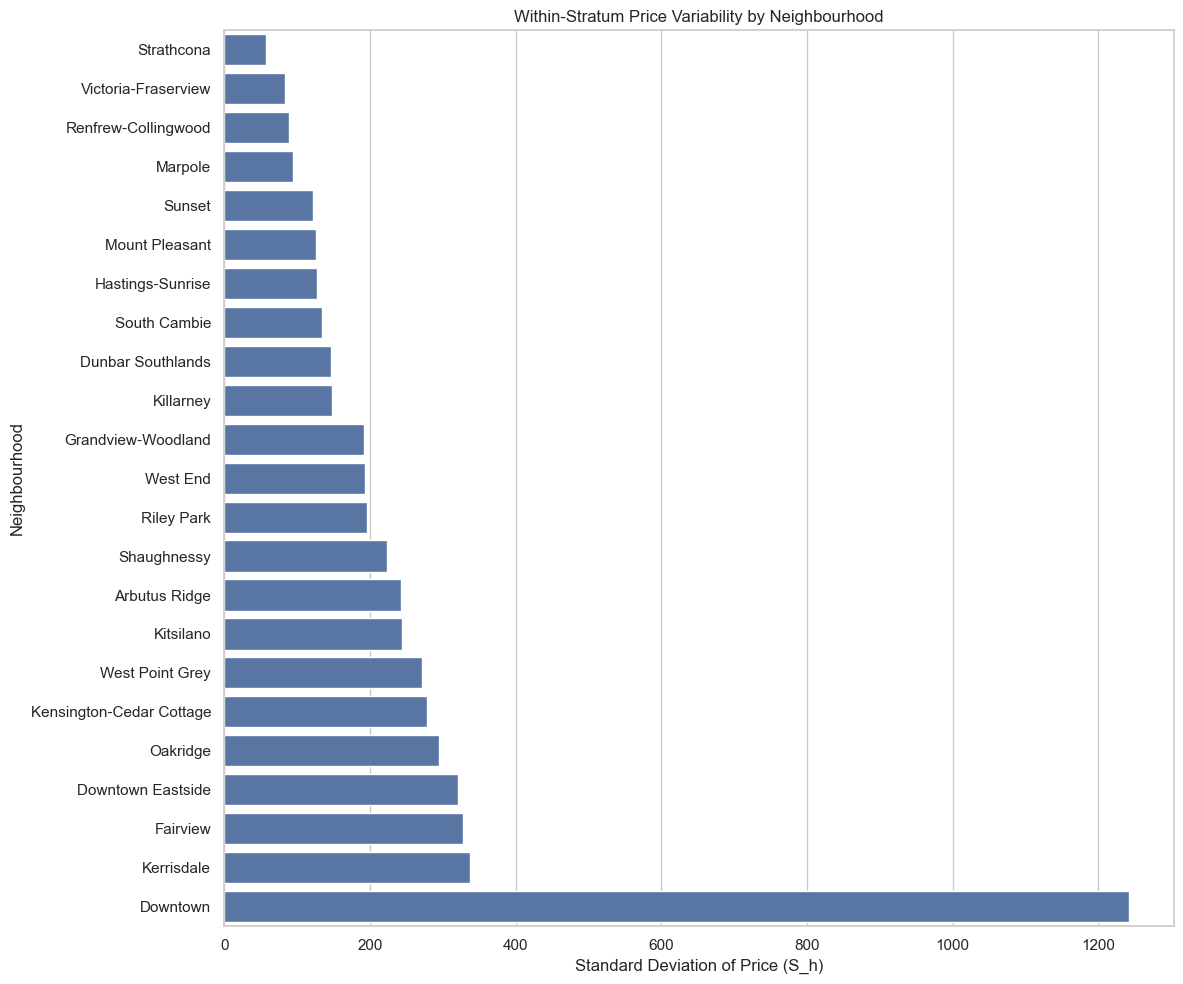

In [97]:
plot_df = stratum_summary.sort_values("S_h", ascending=True)

plt.figure(figsize=(12, 10))
sns.barplot(data=plot_df, y="neighbourhood", x="S_h")
plt.title("Within-Stratum Price Variability by Neighbourhood")
plt.xlabel("Standard Deviation of Price (S_h)")
plt.ylabel("Neighbourhood")
plt.tight_layout()
plt.show()

The sampling preparation checks confirm that the final finite population consists of **N = 4,702** Airbnb listings with observed prices, and that the neighbourhood strata sum exactly to the full population. This means the dataset is now fully prepared for the later sampling procedures, with neighbourhood serving as a complete and workable stratification variable.

The stratum summary shows that the neighbourhoods differ substantially in both **size** and **within-stratum price variability**. In terms of size, **Downtown** is by far the largest stratum with **1,180 listings**, accounting for about **25%** of the total population. It is followed by **Kitsilano (321)**, **Mount Pleasant (306)**, and **Downtown Eastside (297)**. At the other end, **Strathcona** is the only very small stratum, with just **19 listings**. This imbalance in stratum sizes is important because larger neighbourhoods will naturally receive more sampled units under proportional allocation.

The results also show strong differences in within-stratum variability, which is especially relevant for **Neyman allocation**. **Downtown** has by far the highest standard deviation in price (**$1,241.83**), reflecting its very wide spread of listing prices and extreme upper-tail values. Other high-variability neighbourhoods include **Kerrisdale ($336.85)**, **Fairview ($327.20)**, **Downtown Eastside ($320.13)**, and **Oakridge ($294.12)**. These strata would likely receive relatively more sampled units under optimal allocation because they contribute more to the overall variance of the estimator.

Overall, this section confirms that the key quantities needed for stratified sampling are now in place. The neighbourhood strata are clearly unequal in both size and variability, which supports comparing **proportional allocation** and **Neyman allocation** in a later stage of the project.

### 16. Key Findings from EDA

The exploratory data analysis showed that the Vancouver Airbnb dataset is well suited for the sampling analysis in this project. After cleaning the key variables and removing only the **3 listings with missing prices**, the final analysis dataset contains **4,702 listings** with complete information on price, neighbourhood, room type, and number of reviews.

Several important patterns emerged from the EDA. First, nightly Airbnb prices are **strongly right-skewed**, with a mean of **$219.76** and a median of **$158.00**, indicating that a relatively small number of expensive listings pull the average upward. Outlier inspection confirmed that extreme upper-tail prices have a substantial effect on the mean, with the most extreme listing priced at **$40,896**. These values will be retained in the main dataset for now, but their influence will be assessed later through a sensitivity analysis.

Second, the results showed that **neighbourhood is a meaningful and practical stratification variable**. Listings are distributed unevenly across **23 neighbourhoods**, with **Downtown** accounting for about one quarter of the total population. Airbnb prices also vary substantially across neighbourhoods, ranging from lower-price areas such as **Marpole** and **Renfrew-Collingwood** to higher-price areas such as **Downtown**, **Kerrisdale**, and **Kitsilano**. These clear between-neighbourhood differences support the later use of stratified sampling.

Third, room type provides useful descriptive context for the market. The dataset is dominated by **entire home/apartment** listings, which make up nearly **80%** of all observations and are also much more expensive on average than private or shared rooms. This helps explain part of the overall variation in prices across listings.

Finally, the auxiliary variable `number_of_reviews` was found to be **highly right-skewed** and only **very weakly related to price**, with a correlation of **-0.016**. This suggests that while it can still be used in the later ratio estimation analysis, its usefulness as an explanatory or auxiliary variable for price appears limited.

Taken together, the EDA supports the main project design: the data are clean enough for sampling-based estimation, neighbourhood appears to be a strong stratification variable, and outliers are important enough to monitor carefully in the later analysis.

### 17. Next Steps

With the exploratory analysis complete, the next stage of the project is to apply the sampling methods proposed in the study. The first step will be to implement **simple random sampling (SRS)** as a baseline design using the cleaned analysis dataset. This will provide an initial estimate of the mean nightly Airbnb price in Vancouver along with a 95% confidence interval using the finite population correction.

After that, **stratified random sampling by neighbourhood** will be carried out using two allocation methods: **proportional allocation** and **Neyman allocation**. These designs will allow the project to compare whether stratification improves precision relative to SRS, and whether allocating more sampled units to higher-variability neighbourhoods produces additional efficiency gains.

Once the main estimators are computed, the project will compare the sampling designs using their estimated variances, confidence intervals, and the **design effect (DEFF)**. Neighbourhood-level estimates will also be reported to show how Airbnb prices differ across strata.

A separate **ratio estimation analysis** will then be conducted using `number_of_reviews` as the auxiliary variable. Although the EDA suggests only a weak relationship between reviews and price, this component will still be included as a standalone analysis, as originally proposed.

Finally, a **sensitivity analysis** will be performed to evaluate how much the main sampling results depend on the extreme upper-tail price observations identified during EDA. This will make it possible to assess whether the conclusions are robust to outlier treatment and provide a clearer interpretation of the estimated mean nightly Airbnb price in Vancouver.